## COMPETICIÓN RECSYS

GRUPO K
Integrantes
- **Zakaria Lasry Sahraoui**
- **Eder Tarifa Fernández**


### Datos y análisis exploratorio

El dataset de entrenamiento contiene **390.351 valoraciones** de 73.456 usuarios sobre
171.171 ítems, con ratings en el rango [1, 10] y media global de 7.6. La matriz
usuario-ítem presenta una sparsidad prácticamente del 100%, lo que convierte el
problema en un escenario de filtrado colaborativo clásico con fuerte componente de
cold-start: más de 16.000 ítems tienen menos de 5 valoraciones y el conjunto de test
introduce 4.765 usuarios y 16.157 ítems no vistos en entrenamiento.

Antes de entrenar ningún modelo se establecieron las **estrategias de cold-start**
evaluando sistemáticamente distintas pruebas con estadísticos y valores constantes.
Para usuarios desconocidos lo óptimo es devolver el rating constante 8, para ítems 
desconocidos la mediana de valoraciones del usuario, y cuando ambos son desconocidos el rating
constante 7. Estas estrategias se reutilizan en los modelos posteriores.

### KNN colaborativo

Como primera aproximación se implementó un KNN usuario-usuario con distintas métricas
de similaridad (coseno, Jaccard (JMSD), Pearson, Euclidea y Manhattan). La búsqueda en validación
seleccionó **métrica euclídea con k=4**. El KNN actúa como punto de referencia
competitivo para modelos más complejos, y sus predicciones sobre casos conocidos se
usaron más adelante como componente del primer ensemble.

### NMF y BNMF

Antes de pasar a PMF se probaron dos variantes de factorización matricial no negativa:
**NMF** estándar y **BNMF** (con restricción de no negatividad por bias). Ambos
convergen al mismo rango de val MAE (~1.216), sin mejora significativa respecto a
enfoques más simples. La decisión principal para no seguir con esto modelos es que son
mucho más lentos de entrenar respecto a los demás, por tanto se ha priorizado hacer más
pruebas con otros modelos. La restricción de no negatividad no aporta ventaja en un dataset
de ratings con media alta y distribución sesgada hacia valores positivos, por lo que
se descartaron en favor de PMF, que no impone esa restricción.

### PMF y búsqueda de hiperparámetros

La **Factorización Probabilística de Matrices (PMF)** con biases de usuario e ítem y
optimización SGD con Huber loss se convirtió en el modelo central. Se realizaron
**5 rondas de grid search**: la primera con split aleatorio y las siguientes con un
split de tipo **cold-start** (usuarios enteros excluidos del train) para simular mejor
el entorno de evaluación de la competición. El grid se fue refinando progresivamente
en torno al mejor candidato de cada ronda hasta fijar la configuración óptima en
`n_factors=800, lr=0.016, reg=0.10, reg_bias=0.001`.

### Ensemble PMF

Con los hiperparámetros fijados, el siguiente paso fue construir un **ensemble de 9
modelos PMF** entrenados con distintas semillas aleatorias. La motivación es que la
varianza en la inicialización produce modelos que cometen errores distintos y
complementarios; su combinación ponderada por MAE individual en validación reduce la
varianza sin cambiar la arquitectura. Se generaron dos submissions: una con los modelos
entrenados solo sobre train y otra reentrenando sobre train+val, aprovechando todos los
datos disponibles para el test final. Respecto al segundo caso, aunque esto sea una mala
práctica, se ha realizado porque empíricamente se han obtenido mejores resultados. 
Como con esta modalidad no tenemos un conjunto de validación para saber cuando empezamos a
sobreentrenar, se ha seleccionado la media de épocas que se han entrenado los modelos en
la versión en la que si que se disponía de un conjunto de validación, y se han utilizado
esas mismas épocas como forma de parar el entrenamiento.

### LightFM

LightFM es un modelo de factorización que soporta nativamente features de contenido
para usuarios e ítems. En este trabajo **se usa exclusivamente en modo colaborativo**,
sin incorporar ninguna feature externa: el modelo aprecia solo la estructura de
las interacciones, de forma equivalente a PMF pero con una parametrización diferente.
Se exploró el espacio de hiperparámetros variando `n_factors` (800 → 1200),regularización
y learning rate en 7 configuraciones, buscando el punto en que el modelo generaliza sin 
sobreajustarse.

### SVD++

**SVD++** extiende PMF incorporando **feedback implícito**: la representación del
usuario no es solo su vector de factores `U[u]` sino que incluye un término adicional
construido a partir de los ítems que ha valorado, independientemente del valor de
esas valoraciones. Formalmente, `p_u = U[u] + |N(u)|^{-½} Σ_{j∈N(u)} Y[j]`, donde
`Y` es una matriz de factores implícitos aprendida conjuntamente. Esto permite al
modelo capturar preferencias latentes del usuario a partir del patrón de consumo, no
solo de los ratings explícitos. Se probaron 3 configuraciones variando regularización
y learning rate.

### Ensemble multi-modelo

Como paso final se combinaron los tres tipos de modelo en un **ensemble ponderado**
(PMF + SVD++ + LightFM), con 5 instancias de cada tipo y seeds distintas para no entrenar
el mismo modelo en diferentes iteraciones, sumando 15 modelos en total. Los pesos se calculan 
automáticamente como función inversa del MAE individual en validación, para que los modelos 
más precisos contribuyen más a la predicción final. Se generaron igualmente dos versiones: 
entrenando solo sobre train y reentrenando sobre train+val. 

### Notas
Como los modelos son evaluados sobre los datos que si que pueden clasificar (cuando no falta
ni ítem ni usuario), se incluye una función para calcular el MAE "real" ya que lo modelos que hemos ido
entrenando no funcionan cuando el ítem, usuario o ambos faltan en la matriz de entrenamiento.
Por ello, con esta función se tiene en cuenta en los datos de validación los errores
del modelo que sí está clasificando más los errores de nuevas entredas que se clasifican
mediante resultados de estadísticas que se explican más adelante. Esto es un punto importante
porque si se tiene en cuenta solo las predicciones que sí puede hacer el modelo, los resultados
de test son mucho peores y por tanto la métrica de validación no es representativa.

Adjuntamos el archivo ANEXO.ipybn con las ejecuciones del GridSearch searlizado para el modelos PMP.
Por cuestiones temporales no nos ha sido posible incluir la ejecución en este archivo.

In [4]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy import stats
from scipy import stats as sp_stats
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import NMF as SklearnNMF
RATING_MIN = 1.0
RATING_MAX = 10.0
TEST_PATH = 'test.csv'

# Load data and general stats

In [5]:
file = "train.csv"
df = pd.read_csv(file, header=0)
df_test = pd.read_csv(TEST_PATH, header=0)
df.head()

,user,item,rating
0,1,25715,7.0
1,1,25716,10.0
2,5,25851,9.0
3,6,25923,5.0
4,7,25924,6.0


In [6]:
df["rating"].min(), df["user"].unique().shape[0], df.shape

(np.float64(1.0), 73456, (390351, 3))

In [7]:
y = df["rating"]
x = df.drop(columns="rating")

In [8]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=42, stratify=df.rating)

In [9]:
x_train.shape, x_val.shape

((351315, 2), (39036, 2))

# EDA

In [23]:
n_users   = df['user'].nunique()
n_items   = df['item'].nunique()
n_ratings = len(df)
sparsity  = 1 - n_ratings / (n_users * n_items)
mu_global = df['rating'].mean()

ratings_per_user = df.groupby('user').size()
ratings_per_item = df.groupby('item').size()
cold_items = (ratings_per_item == 5).sum()
cold_users = (ratings_per_user == 5).sum()

stats = pd.DataFrame({
    'Métrica': ['Usuarios', 'Items', 'Ratings', 'Sparsidad',
                'Rating medio', 'Desv. típica',
                'Mediana ratings/usuario', 'Items cold-start (=0)',
                'Usuarios cold-start (=0)'],
    'Valor':   [f'{n_users:,}', f'{n_items:,}', f'{n_ratings:,}',
                f'{sparsity*100:.2f}%', f'{mu_global:.3f}',
                f'{df["rating"].std():.3f}',
                f'{ratings_per_user.median():.0f}',
                f'{cold_items} ({cold_items/n_items*100:.1f}%)',
                f'{cold_users} ({cold_users/n_users*100:.1f}%)']
})
display(stats.set_index('Métrica'))

,Valor
Métrica,
Usuarios,"73,456"
Items,"171,171"
Ratings,"390,351"
Sparsidad,100.00%
Rating medio,7.605
Desv. típica,1.843
Mediana ratings/usuario,1
Items cold-start (=0),2969 (1.7%)
Usuarios cold-start (=0),2072 (2.8%)


In [24]:
from scipy.sparse import csr_matrix

user2idx = {u: i for i, u in enumerate(sorted(df['user'].unique()))}
item2idx = {it: i for i, it in enumerate(sorted(df['item'].unique()))}

df = df.copy()
df['user'] = df['user'].map(user2idx)
df['item'] = df['item'].map(item2idx)

N_USERS = len(user2idx)
N_ITEMS = len(item2idx)

np.random.seed(24)
idx_all = np.random.permutation(len(df))
n_val   = int(len(df) * 0.10)

val_df   = df.iloc[idx_all[:n_val]].reset_index(drop=True)
train_df = df.iloc[idx_all[n_val:]].reset_index(drop=True)
test_df  = val_df

print(f'Train : {len(train_df):,}  ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):,}  ({len(val_df)/len(df)*100:.1f}%)')
print(f'N_USERS={N_USERS} | N_ITEMS={N_ITEMS}')

R_sparse = csr_matrix(
    (train_df['rating'].values, (train_df['user'].values, train_df['item'].values)),
    shape=(N_USERS, N_ITEMS)
)
print(f'\nR_sparse: {R_sparse.shape} | nnz={R_sparse.nnz:,} | '
      f'sparsidad: {(1 - R_sparse.nnz/(N_USERS*N_ITEMS))*100:.1f}%')

R_train = None

df_test_comp = pd.read_csv(TEST_PATH)
df_test_comp['user'] = df_test_comp['user'].map(user2idx).fillna(-1).astype(int)
df_test_comp['item'] = df_test_comp['item'].map(item2idx).fillna(-1).astype(int)

print(f'\nTest competición: {len(df_test_comp):,} pares a predecir')
cold_u = (df_test_comp['user'] == -1).sum()
cold_i = (df_test_comp['item'] == -1).sum()
if cold_u or cold_i:
    print(f' Cold-start: {cold_u} usuarios y {cold_i} items no vistos en train')

Train : 351,316  (90.0%)
Val   : 39,035  (10.0%)
N_USERS=73456 | N_ITEMS=171171

R_sparse: (73456, 171171) | nnz=351,316 | sparsidad: 100.0%

Test competición: 43,320 pares a predecir


In [ ]:
def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))


def evaluar(nombre, predict_fn, eval_df, verbose=True):
    y_true, y_pred = [], []
    for row in eval_df.itertuples():
        pred = float(np.clip(predict_fn(row.user, row.item), RATING_MIN, RATING_MAX))
        y_true.append(row.rating)
        y_pred.append(pred)
    score = mae(y_true, y_pred)
    if verbose:
        print(f'  {nombre:<8}  MAE = {score:.4f}')
    return {'modelo': nombre, 'MAE': score}


resultados = []
print(f'Métrica MAE lista. Clamp: [{RATING_MIN}, {RATING_MAX}]')

mu_global        = df['rating'].mean()
item_means       = df.groupby('item')['rating'].mean()
user_means_train = df.groupby('user')['rating'].mean()

def predict_mean(user, item):
    return mu_global

def predict_item_mean(user, item):
    return item_means.get(item, mu_global)

def predict_user_mean(user, item):
    return user_means_train.get(user, mu_global)

res_mean      = evaluar('MediaGlobal', predict_mean,      test_df)
res_item_mean = evaluar('MediaItem',   predict_item_mean, test_df)
res_user_mean = evaluar('MediaUser',   predict_user_mean, test_df)

resultados.extend([res_mean, res_item_mean, res_user_mean])

Métrica MAE lista. Clamp: [1.0, 10.0]
  MediaGlobal  MAE = 1.4921
  MediaItem  MAE = 0.8231
  MediaUser  MAE = 1.0059


Rango de ratings: [1.0, 10.0]
Dimensiones train: (390351, 3)
Rango ratings: [1.0, 10.0]


,Valor
Métrica,
Usuarios,"73,456"
Items,"171,171"
Ratings,"390,351"
Sparsidad,100.00%
Rating medio,7.605
Desv. típica,1.843
Mediana ratings/usuario,1
Items cold-start (<5),158169 (92.4%)


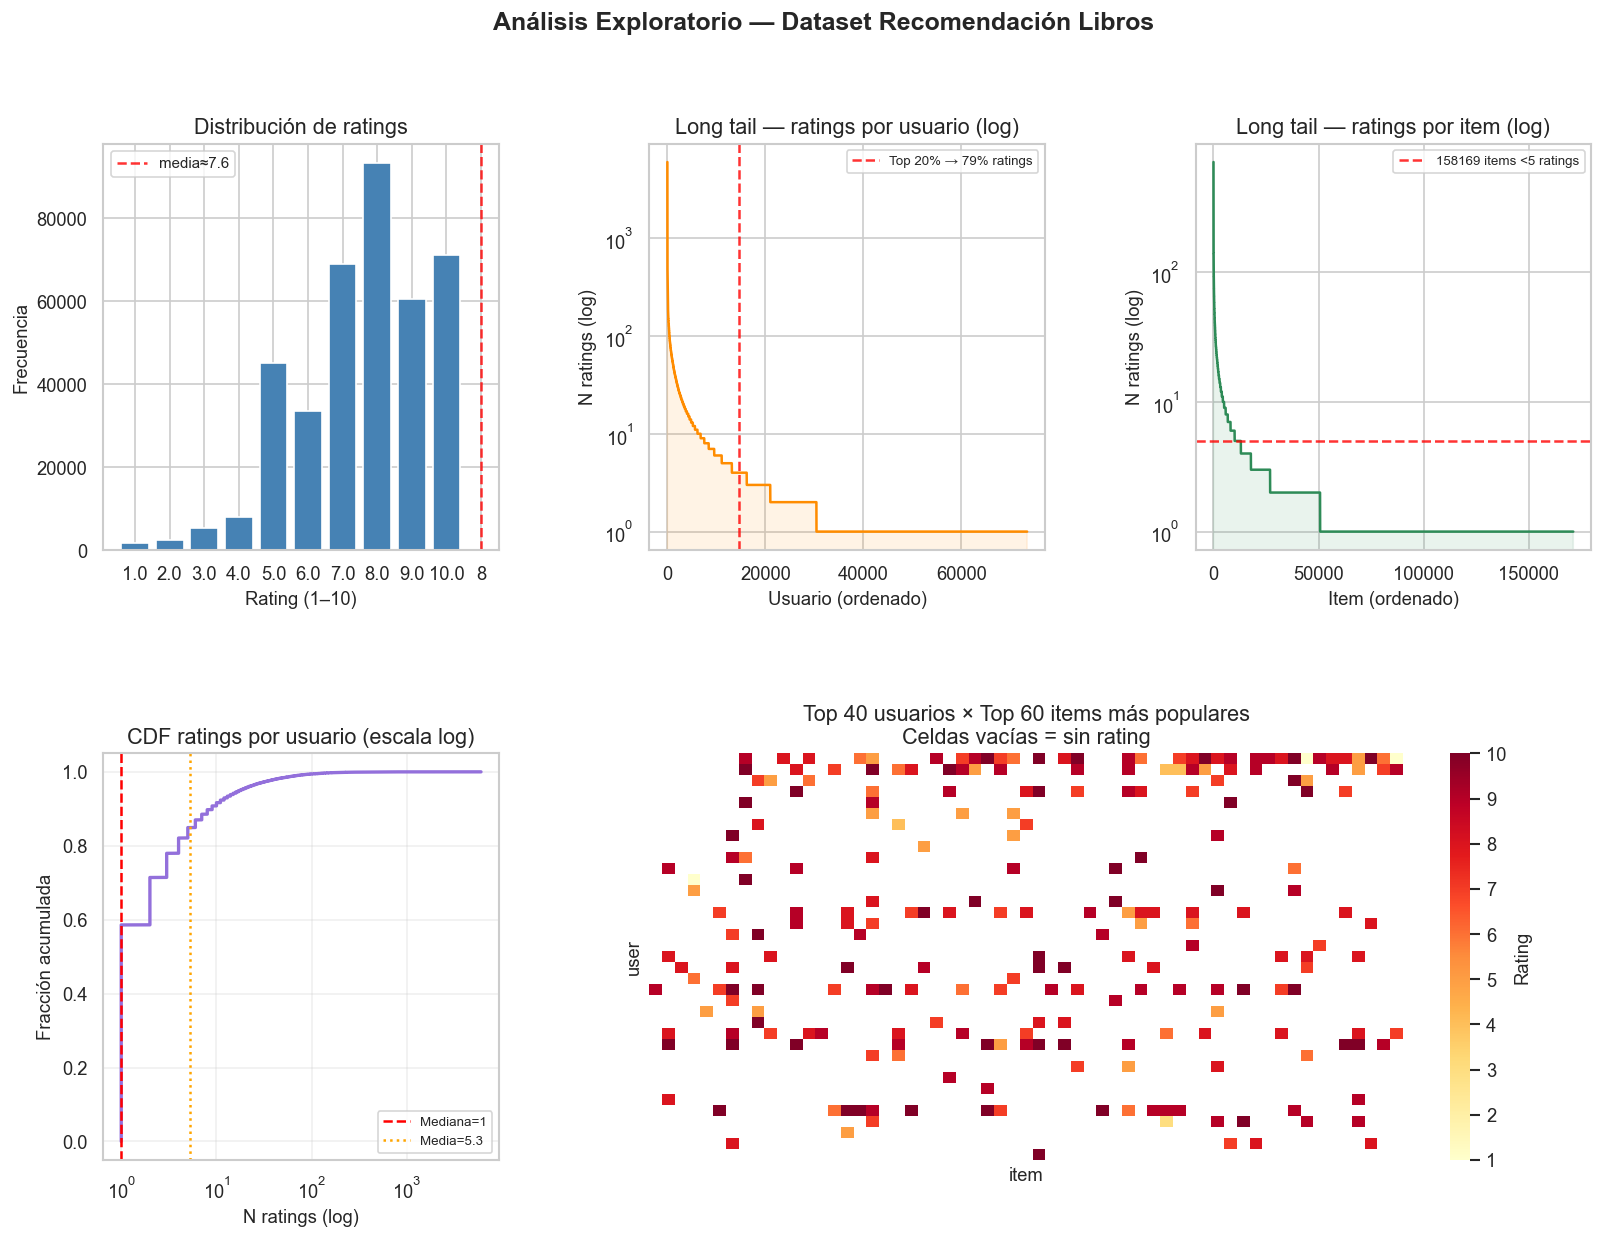


Conclusiones EDA:
  Ratings 1–10 (media=7.60): sesgo hacia puntuaciones altas.
  Sparsidad 100.0%: la mayoría de pares usuario-item no tienen rating.
  Mediana 1 rating/usuario: long tail extrema, KNN sufre.
  158169 items cold-start (92.4%): fallback a media global necesario.
No hay ratings duplicados — no se puede estimar directamente
Desviación típica media intra-usuario: 1.3532
Ceiling teórico aproximado: ~0.9473


In [ ]:
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

N_FACTORS = 20
N_EPOCHS  = 50
LR        = 0.005
REG       = 0.02
K_KNN     = 20

print(f'Rango de ratings: [{RATING_MIN}, {RATING_MAX}]')
df_test = pd.read_csv(TEST_PATH)
df_test['user'] = df_test['user'].map(user2idx).fillna(-1).astype(int)
df_test['item'] = df_test['item'].map(item2idx).fillna(-1).astype(int)

df_ratings = df.copy()
df_ratings = df_ratings[['user', 'item', 'rating']]

print(f'Dimensiones train: {df_ratings.shape}')
print(f'Rango ratings: [{df_ratings["rating"].min()}, {df_ratings["rating"].max()}]')
df_ratings.head()

n_users   = df_ratings['user'].nunique()
n_items   = df_ratings['item'].nunique()
ratings_per_user = df_ratings.groupby('user').size()
ratings_per_item = df_ratings.groupby('item').size()

n_ratings = len(df_ratings)
sparsity  = 1 - n_ratings / (n_users * n_items)
mu_global = df_ratings['rating'].mean()

cold_items = (ratings_per_item < 5).sum()
cold_users = (ratings_per_user < 5).sum()

stats = pd.DataFrame({
    'Métrica': ['Usuarios', 'Items', 'Ratings', 'Sparsidad',
                'Rating medio', 'Desv. típica',
                'Mediana ratings/usuario', 'Items cold-start (<5)'],
    'Valor':   [f'{n_users:,}', f'{n_items:,}', f'{n_ratings:,}',
                f'{sparsity*100:.2f}%', f'{mu_global:.3f}',
                f'{df_ratings["rating"].std():.3f}',
                f'{ratings_per_user.median():.0f}',
                f'{cold_items} ({cold_items/n_items*100:.1f}%)']
})
display(stats.set_index('Métrica'))


fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

# Distribución de ratings
ax1 = fig.add_subplot(gs[0, 0])
counts = df_ratings['rating'].value_counts().sort_index()
bars = ax1.bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
ax1.axvline(str(round(mu_global)), color='red', linestyle='--', alpha=0.8,
            label=f'media≈{mu_global:.1f}')
ax1.set_title('Distribución de ratings')
ax1.set_xlabel('Rating (1–10)'); ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
su  = ratings_per_user.sort_values(ascending=False).values
ax2.semilogy(su, color='darkorange', linewidth=1.5)
ax2.fill_between(range(len(su)), su, alpha=0.1, color='darkorange')
p20   = int(len(su) * 0.2)
pct_u = su[:p20].sum() / n_ratings * 100
ax2.axvline(p20, color='red', linestyle='--', alpha=0.8,
            label=f'Top 20% → {pct_u:.0f}% ratings')
ax2.set_title('Long tail — ratings por usuario (log)')
ax2.set_xlabel('Usuario (ordenado)'); ax2.set_ylabel('N ratings (log)')
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[0, 2])
si  = ratings_per_item.sort_values(ascending=False).values
ax3.semilogy(si, color='seagreen', linewidth=1.5)
ax3.fill_between(range(len(si)), si, alpha=0.1, color='seagreen')
ax3.axhline(5, color='red', linestyle='--', alpha=0.8,
            label=f'{cold_items} items <5 ratings')
ax3.set_title('Long tail — ratings por item (log)')
ax3.set_xlabel('Item (ordenado)'); ax3.set_ylabel('N ratings (log)')
ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[1, 0])
sorted_u = np.sort(ratings_per_user.values)
cdf = np.arange(1, len(sorted_u)+1) / len(sorted_u)
ax4.plot(sorted_u, cdf, color='mediumpurple', linewidth=2)
ax4.axvline(ratings_per_user.median(), color='red', linestyle='--',
            label=f'Mediana={ratings_per_user.median():.0f}')
ax4.axvline(ratings_per_user.mean(), color='orange', linestyle=':',
            label=f'Media={ratings_per_user.mean():.1f}')
ax4.set_xscale('log')
ax4.set_title('CDF ratings por usuario (escala log)')
ax4.set_xlabel('N ratings (log)'); ax4.set_ylabel('Fracción acumulada')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1:])
top_u  = ratings_per_user.nlargest(40).index
pop_i  = ratings_per_item.nlargest(60).index
pivot  = df_ratings[
    df_ratings['user'].isin(top_u) & df_ratings['item'].isin(pop_i)
].pivot_table(index='user', columns='item', values='rating')
sns.heatmap(pivot, ax=ax5, cmap='YlOrRd', vmin=RATING_MIN, vmax=RATING_MAX,
            cbar_kws={'label': 'Rating'}, xticklabels=False, yticklabels=False,
            linewidths=0)
ax5.set_title('Top 40 usuarios × Top 60 items más populares\nCeldas vacías = sin rating')

fig.suptitle('Análisis Exploratorio — Dataset Recomendación Libros', fontsize=15, fontweight='bold')
plt.savefig('eda.png', bbox_inches='tight'); plt.show()

print('\nConclusiones EDA:')
print(f'  Ratings 1–10 (media={mu_global:.2f}): sesgo hacia puntuaciones altas.')
print(f'  Sparsidad {sparsity*100:.1f}%: la mayoría de pares usuario-item no tienen rating.')
print(f'  Mediana {ratings_per_user.median():.0f} rating/usuario: long tail extrema, KNN sufre.')
print(f'  {cold_items} items cold-start ({cold_items/n_items*100:.1f}%): fallback a media global necesario.')

duplicados = df_ratings.groupby(['user', 'item']).size()
duplicados = duplicados[duplicados > 1]

if len(duplicados) > 0:
    pairs = df_ratings.groupby(['user', 'item'])['rating'].apply(list)
    pairs_multi = pairs[pairs.apply(len) > 1]
    errores = []
    for ratings_list in pairs_multi:
        media = np.mean(ratings_list)
        for r in ratings_list:
            errores.append(abs(r - media))
    print(f'Error de Bayes estimado: {np.mean(errores):.4f}')
else:
    print('No hay ratings duplicados — no se puede estimar directamente')
    std_intra = df_ratings.groupby('user')['rating'].std().dropna().mean()
    print(f'Desviación típica media intra-usuario: {std_intra:.4f}')
    print(f'Ceiling teórico aproximado: ~{std_intra * 0.7:.4f}')

# Functions for training

In [ ]:
def create_sparse_matrix(x_train, y_train):
    user_map = {u: i for i, u in enumerate(x_train['user'].unique())}
    item_map = {it: i for i, it in enumerate(x_train['item'].unique())}

    row = x_train['user'].map(user_map)
    col = x_train['item'].map(item_map)
    data = y_train.values

    sparse_matrix = csr_matrix(
        (data, (row, col)),
        shape=(len(user_map), len(item_map))
        ) 
    return sparse_matrix, user_map, item_map

def compute_stats(sparse_matrix):
    csr = sparse_matrix.tocsr()
    csc = sparse_matrix.tocsc()

    user_sums   = np.array(csr.sum(axis=1)).flatten()
    user_counts = np.diff(csr.indptr)
    user_means  = np.where(user_counts > 0, user_sums / user_counts, np.nan)

    item_sums   = np.array(csc.sum(axis=0)).flatten()
    item_counts = np.diff(csc.indptr)
    item_means  = np.where(item_counts > 0, item_sums / item_counts, np.nan)

    global_mean = float(csr.data.mean()) if len(csr.data) > 0 else 0.0

    return user_means, item_means, global_mean


def get_user_distances_for_item(user_idx, item_idx, sparse_matrix, metrics, user_means):
    vec_a     = sparse_matrix[user_idx].toarray().flatten()
    nonzero_a = set(np.where(vec_a != 0)[0])
    mean_a    = user_means[user_idx]

    item_col          = sparse_matrix[:, item_idx].toarray().flatten()
    candidate_indices = np.where(
        (item_col != 0) & (np.arange(len(item_col)) != user_idx)
    )[0]

    if len(candidate_indices) == 0:
        return {m: np.array([]) for m in metrics}, np.array([]), np.array([])

    distances = {m: [] for m in metrics}
    ratings, valid_idx = [], []

    for j in candidate_indices:
        vec_b  = sparse_matrix[j].toarray().flatten()
        common = list(nonzero_a & set(np.where(vec_b != 0)[0]))
        if len(common) == 0:
            continue

        a, b   = vec_a[common], vec_b[common]
        mean_b = user_means[j]
        metric_results = {}

        if 'cosine' in metrics:
            norm = np.linalg.norm(a) * np.linalg.norm(b)
            metric_results['cosine'] = 1 - (np.dot(a, b) / norm) if norm > 0 else None

        if 'euclidean' in metrics:
            metric_results['euclidean'] = np.sqrt(np.sum((a - b) ** 2))

        if 'euclidean_bias' in metrics:
            if np.isnan(mean_a) or np.isnan(mean_b):
                metric_results['euclidean_bias'] = None
            else:
                metric_results['euclidean_bias'] = np.sqrt(
                    np.sum(((a - mean_a) - (b - mean_b)) ** 2)
                )

        if 'pearson' in metrics:
            if np.std(a) == 0 or np.std(b) == 0:
                metric_results['pearson'] = None
            else:
                metric_results['pearson'] = 1 - np.corrcoef(a, b)[0, 1]
        
        if 'manhattan' in metrics:
            metric_results['manhattan'] = np.sum(np.abs(a - b))

        if 'jaccard_weighted' in metrics:
            if np.isnan(mean_a) or np.isnan(mean_b):
                metric_results['jaccard_weighted'] = None
            else:
                a_n = a - mean_a
                b_n = b - mean_b
                numerator = np.sum(np.minimum(np.abs(a_n), np.abs(b_n)))
                denominator = np.sum(np.maximum(np.abs(a_n), np.abs(b_n)))

                if denominator == 0:
                    metric_results['jaccard_weighted'] = None
                else:
                    metric_results['jaccard_weighted'] = 1 - (numerator / denominator)

        if any(v is None for v in metric_results.values()):
            continue

        for m in metrics:
            distances[m].append(metric_results[m])
        ratings.append(item_col[j])
        valid_idx.append(j)

    return (
        {m: np.array(distances[m]) for m in metrics},
        np.array(ratings),
        np.array(valid_idx)
    )

def _expand_strategies(strats):
    expanded = []
    for s in strats:
        if s == 'range_1_10':
            expanded.extend([f'const_{v}' for v in range(1, 11)])
        else:
            expanded.append(s)
    return expanded


def evaluate_knn(x_val, y_val, sparse_matrix, user_map, item_map,
                 k_max=20, metrics=('cosine',), error_metric='rmse',
                 cold_start=None):
    if cold_start is None:
        cold_start = {
            'unknown_user' : ['item_mean', 'global_mean', 'range_1_10'],
            'unknown_item' : ['user_mean', 'global_mean', 'range_1_10'],
            'both_unknown' : ['global_mean', 'range_1_10'],
        }

    cold_start = {case: _expand_strategies(strats) for case, strats in cold_start.items()}

    metrics  = list(metrics)
    k_values = list(range(2, k_max + 1))

    user_means, item_means, global_mean = compute_stats(sparse_matrix)

    val_df = x_val.copy()
    val_df['y_true'] = y_val.values
    val_df.columns   = ['user', 'item', 'y_true']

    knn_errors = {m: {k: [] for k in k_values} for m in metrics}
    cs_errors  = {
        case: {strat: [] for strat in strats}
        for case, strats in cold_start.items()
    }

    def _cold_pred(strat, user_idx=None, item_idx=None):
        if strat == 'item_mean':
            v = item_means[item_idx] if item_idx is not None else np.nan
        elif strat == 'user_mean':
            v = user_means[user_idx] if user_idx is not None else np.nan
        elif strat == 'global_mean':
            v = global_mean
        elif strat.startswith('const_'):
            v = float(strat.split('_')[1])
        else:
            v = np.nan
        return global_mean if (isinstance(v, float) and np.isnan(v)) else v

    def _err(pred, true):
        return (pred - true) ** 2 if error_metric == 'rmse' else abs(pred - true)

    for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="Evaluating"):
        user_id, item_id, y_true = row['user'], row['item'], row['y_true']

        user_known = user_id in user_map
        item_known = item_id in item_map

        if not user_known or not item_known:
            if not user_known and not item_known:
                case = 'both_unknown'
                for strat in cold_start.get(case, []):
                    cs_errors[case][strat].append(_err(_cold_pred(strat), y_true))

            elif not user_known:
                case     = 'unknown_user'
                item_idx = item_map[item_id]
                for strat in cold_start.get(case, []):
                    cs_errors[case][strat].append(
                        _err(_cold_pred(strat, item_idx=item_idx), y_true)
                    )
            else:
                case     = 'unknown_item'
                user_idx = user_map[user_id]
                for strat in cold_start.get(case, []):
                    cs_errors[case][strat].append(
                        _err(_cold_pred(strat, user_idx=user_idx), y_true)
                    )
            continue

        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        dist_by_metric, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, metrics, user_means
        )

        if len(ratings) == 0:
            continue

        for m in metrics:
            distances = dist_by_metric[m]
            if len(distances) == 0:
                continue
            sorted_idx = np.argsort(distances)
            for k in k_values:
                k_actual = min(k, len(sorted_idx))
                top_idx  = sorted_idx[:k_actual]
                top_d    = distances[top_idx]
                top_r    = ratings[top_idx]
                weights  = 1 / (top_d + 1e-8)
                pred     = np.dot(weights, top_r) / weights.sum()
                knn_errors[m][k].append(_err(pred, y_true))

    def _agg(lst):
        if not lst:
            return np.nan
        return np.sqrt(np.mean(lst)) if error_metric == 'rmse' else np.mean(lst)

    knn_results = {
        m: (k_values, [_agg(knn_errors[m][k]) for k in k_values])
        for m in metrics
    }
    cs_results = {
        case: {strat: _agg(errs) for strat, errs in strats.items()}
        for case, strats in cs_errors.items()
    }

    return {'knn': knn_results, 'cold_start': cs_results}

def predict(x_test, sparse_matrix, user_map, item_map,
            user_means, item_means, global_mean,
            metric='jaccard_weighted', k=5,
            cold_start_unknown_user='global_mean',
            cold_start_unknown_item='user_mean',
            cold_start_both='const_7'):

    def _cold_pred(strat, user_idx=None, item_idx=None):
        if strat == 'item_mean':
            v = item_means[item_idx] if item_idx is not None else np.nan
        elif strat == 'user_mean':
            v = user_means[user_idx] if user_idx is not None else np.nan
        elif strat == 'global_mean':
            v = global_mean
        elif strat.startswith('const_'):
            v = float(strat.split('_')[1])
        else:
            v = np.nan
        return global_mean if (isinstance(v, float) and np.isnan(v)) else v

    ids   = []
    preds = []

    for _, row in tqdm(x_test.iterrows(), total=len(x_test), desc="Predicting"):
        row_id  = row.iloc[0] 
        user_id = row.iloc[1]
        item_id = row.iloc[2]

        user_known = user_id in user_map
        item_known = item_id in item_map

        ids.append(row_id)

        if not user_known and not item_known:
            preds.append(_cold_pred(cold_start_both))
            continue

        if not user_known:
            item_idx = item_map[item_id]
            preds.append(_cold_pred(cold_start_unknown_user, item_idx=item_idx))
            continue

        if not item_known:
            user_idx = user_map[user_id]
            preds.append(_cold_pred(cold_start_unknown_item, user_idx=user_idx))
            continue

        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        distances, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, [metric], user_means
        )
        distances = distances[metric]

        if len(distances) == 0:
            preds.append(_cold_pred(cold_start_unknown_item, user_idx=user_idx))
            continue

        sorted_idx = np.argsort(distances)
        k_actual   = min(k, len(sorted_idx))
        top_idx    = sorted_idx[:k_actual]
        top_d      = distances[top_idx]
        top_r      = ratings[top_idx]
        weights    = 1 / (top_d + 1e-8)
        pred       = np.dot(weights, top_r) / weights.sum()

        preds.append(pred)

    return pd.DataFrame({'id': ids, 'rating': preds})


def analyze_coldstart(x_train, y_train, x_val, y_val, user_map, item_map):

    all_ratings    = y_train.values
    global_mean    = float(np.mean(all_ratings))
    global_median  = float(np.median(all_ratings))
    global_mode    = float(sp_stats.mode(all_ratings, keepdims=True).mode[0])

    train_df = x_train.copy()
    train_df.columns = ['user', 'item']
    train_df['rating'] = y_train.values

    user_stats = train_df.groupby('user')['rating'].agg(
        mean='mean', median='median',
        mode=lambda x: sp_stats.mode(x, keepdims=True).mode[0]
    )
    item_stats = train_df.groupby('item')['rating'].agg(
        mean='mean', median='median',
        mode=lambda x: sp_stats.mode(x, keepdims=True).mode[0]
    )

    val_df = x_val.copy()
    val_df.columns = ['user', 'item']
    val_df['rating'] = y_val.values
    val_df['u_known'] = val_df['user'].isin(user_map)
    val_df['i_known'] = val_df['item'].isin(item_map)

    cases = {
        'unknown_user' : val_df[ val_df['u_known'] & ~val_df['i_known']],
        'unknown_item' : val_df[~val_df['u_known'] &  val_df['i_known']],
        'both_unknown' : val_df[~val_df['u_known'] & ~val_df['i_known']],
    }
    cases = {
        'unknown_user' : val_df[~val_df['u_known'] &  val_df['i_known']],
        'unknown_item' : val_df[ val_df['u_known'] & ~val_df['i_known']],
        'both_unknown' : val_df[~val_df['u_known'] & ~val_df['i_known']],
    }

    print(f"Casos cold-start en validación:")
    for case, df in cases.items():
        print(f"  {case:<15}: {len(df):>5} ({len(df)/len(val_df)*100:.1f}%)")

    best_strategies = {}

    for case, df in cases.items():
        if len(df) == 0:
            print(f"\n[{case}] Sin casos en validación, skipping.")
            continue

        y_true = df['rating'].values

        strategies = {}

        for v in range(1, 11):
            strategies[f'const_{v}'] = np.full(len(df), float(v))

        strategies['global_mean']   = np.full(len(df), global_mean)
        strategies['global_median'] = np.full(len(df), global_median)
        strategies['global_mode']   = np.full(len(df), global_mode)

        if case == 'unknown_user':
            item_mean_preds, item_med_preds, item_mode_preds = [], [], []
            for item_id in df['item']:
                if item_id in item_stats.index:
                    item_mean_preds.append(item_stats.loc[item_id, 'mean'])
                    item_med_preds.append(item_stats.loc[item_id, 'median'])
                    item_mode_preds.append(item_stats.loc[item_id, 'mode'])
                else:
                    item_mean_preds.append(global_mean)
                    item_med_preds.append(global_median)
                    item_mode_preds.append(global_mode)
            strategies['item_mean']   = np.array(item_mean_preds)
            strategies['item_median'] = np.array(item_med_preds)
            strategies['item_mode']   = np.array(item_mode_preds)

        if case == 'unknown_item':
            user_mean_preds, user_med_preds, user_mode_preds = [], [], []
            for user_id in df['user']:
                if user_id in user_stats.index:
                    user_mean_preds.append(user_stats.loc[user_id, 'mean'])
                    user_med_preds.append(user_stats.loc[user_id, 'median'])
                    user_mode_preds.append(user_stats.loc[user_id, 'mode'])
                else:
                    user_mean_preds.append(global_mean)
                    user_med_preds.append(global_median)
                    user_mode_preds.append(global_mode)
            strategies['user_mean']   = np.array(user_mean_preds)
            strategies['user_median'] = np.array(user_med_preds)
            strategies['user_mode']   = np.array(user_mode_preds)

        results = {}
        for name, preds in strategies.items():
            results[name] = float(np.mean(np.abs(preds - y_true)))

        results_df = pd.DataFrame({'strategy': list(results.keys()),
                                   'mae': list(results.values())})
        results_df = results_df.sort_values('mae').reset_index(drop=True)
        best_strat = results_df.iloc[0]['strategy']
        best_strategies[case] = {
            'strategy' : best_strat,
            'mae'      : results_df.iloc[0]['mae'],
            'all'      : results_df
        }

        print(f"\n── {case} (n={len(df)}) ──────────────────────────────")
        print(results_df.to_string(index=False))
        print(f"  → Mejor estrategia: {best_strat} (MAE={results_df.iloc[0]['mae']:.4f})")

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

        colors = ['#70ad47' if s == best_strat else
                  '#5b9bd5' if s.startswith('const_') else
                  '#ed7d31' if 'mean' in s or 'median' in s or 'mode' in s else
                  '#a9a9a9'
                  for s in results_df['strategy']]

        bars = ax1.bar(range(len(results_df)), results_df['mae'],
                       color=colors, edgecolor='white')
        ax1.set_xticks(range(len(results_df)))
        ax1.set_xticklabels(results_df['strategy'], rotation=45, ha='right', fontsize=8)
        ax1.set_ylabel('MAE')
        ax1.set_title(f'[{case}] MAE por estrategia')
        ax1.grid(True, axis='y', alpha=0.4)

        y_off = (results_df['mae'].max() - results_df['mae'].min()) * 0.01 + 0.001
        for bar, val in zip(bars, results_df['mae']):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_off,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=7)

        from matplotlib.patches import Patch
        ax1.legend(handles=[
            Patch(color='#70ad47', label='Best'),
            Patch(color='#5b9bd5', label='Constant (1-10)'),
            Patch(color='#ed7d31', label='Stat-based'),
        ], fontsize=8)

        ax2.hist(y_true, bins=np.arange(0.5, 11.5, 1), color='steelblue',
                 edgecolor='white', alpha=0.8)
        ax2.axvline(global_mean,   color='red',    linestyle='--', label=f'global mean={global_mean:.2f}')
        ax2.axvline(global_median, color='orange', linestyle='--', label=f'global median={global_median:.2f}')
        ax2.set_xlabel('Rating')
        ax2.set_ylabel('Count')
        ax2.set_title(f'[{case}] Distribución de ratings reales')
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.4)

        fig.suptitle(f'Cold-start analysis — {case}', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return best_strategies, user_stats, item_stats, global_mean



def plot_knn_error(results, error_metric='mae'):
    knn_results = results['knn']
    knn_colors  = ['steelblue', 'darkorange', 'seagreen', 'crimson',
                   'mediumpurple', 'saddlebrown']
    best_ks = {}

    fig, ax = plt.subplots(figsize=(13, 6))

    for i, (metric, (k_values, errors)) in enumerate(knn_results.items()):
        color  = knn_colors[i % len(knn_colors)]
        best_k = k_values[int(np.nanargmin(errors))]
        best_ks[metric] = best_k
        ax.plot(
            k_values, errors,
            marker='o', linewidth=2, color=color,
            label=f'{metric}  (best k={best_k}, {error_metric.upper()}={np.nanmin(errors):.4f})'
        )
        ax.axvline(best_k, color=color, linestyle='--', alpha=0.35)

    ax.set_xlabel('k', fontsize=12)
    ax.set_ylabel(error_metric.upper(), fontsize=12)
    ax.set_title(f'KNN validation error vs k — {error_metric.upper()}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.4)
    fig.tight_layout()
    plt.show()

    return best_ks

# Statistics and KNN model

Casos cold-start en validación:
  unknown_user   :  3264 (8.4%)
  unknown_item   : 11212 (28.7%)
  both_unknown   :  1317 (3.4%)

── unknown_user (n=3264) ──────────────────────────────
     strategy      mae
      const_8 1.369792
global_median 1.369792
  global_mode 1.369792
  global_mean 1.428172
  item_median 1.458333
    item_mean 1.459555
      const_7 1.517463
    item_mode 1.649510
      const_9 1.754596
      const_6 2.043199
     const_10 2.439645
      const_5 2.750306
      const_4 3.648591
      const_3 4.594056
      const_2 5.570772
      const_1 6.560355
  → Mejor estrategia: const_8 (MAE=1.3698)


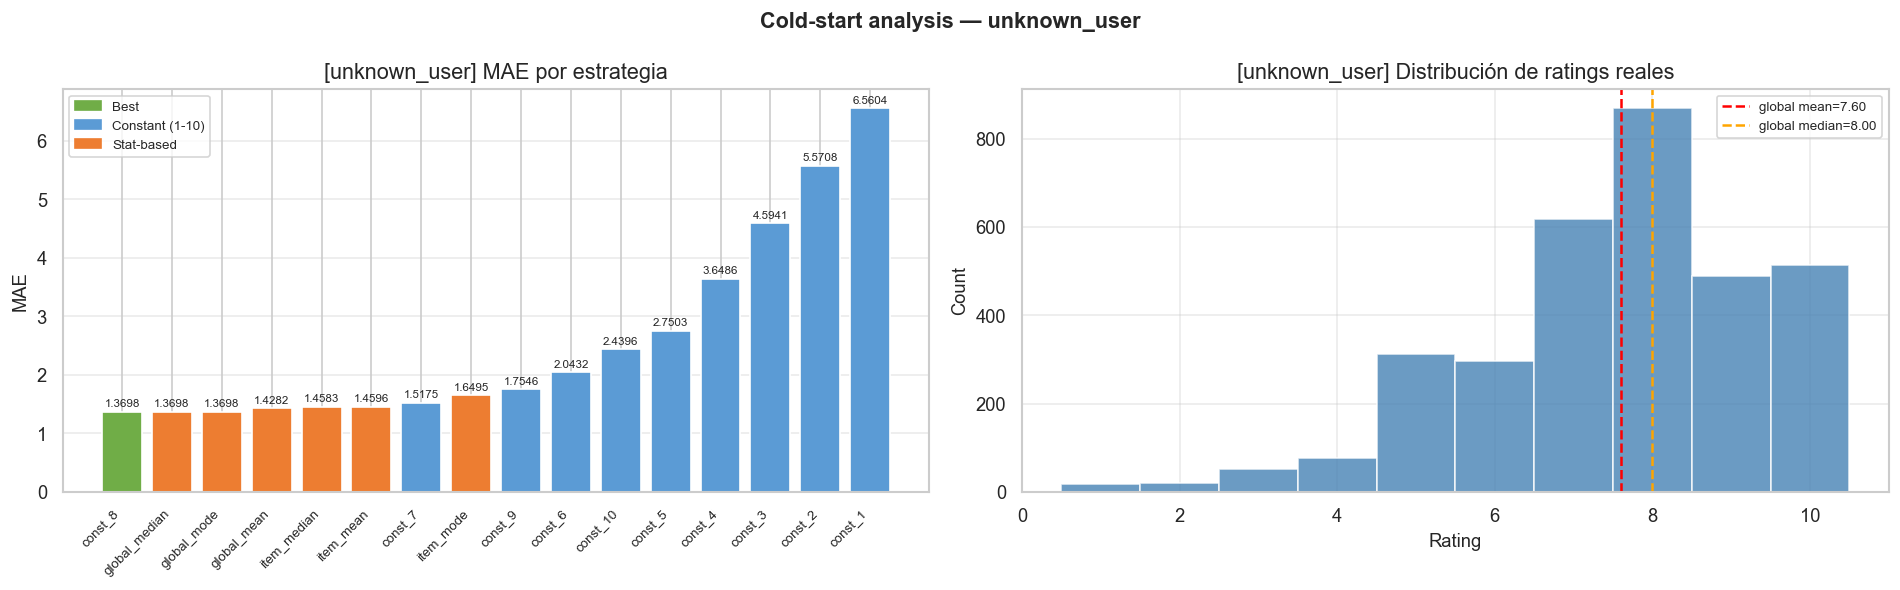


── unknown_item (n=11212) ──────────────────────────────
     strategy      mae
  user_median 1.209329
    user_mean 1.248337
    user_mode 1.323403
      const_8 1.530503
global_median 1.530503
  global_mode 1.530503
  global_mean 1.560968
      const_7 1.607563
      const_9 1.890474
      const_6 2.037103
     const_10 2.528541
      const_5 2.648056
      const_4 3.553157
      const_3 4.502854
      const_2 5.480557
      const_1 6.471459
  → Mejor estrategia: user_median (MAE=1.2093)


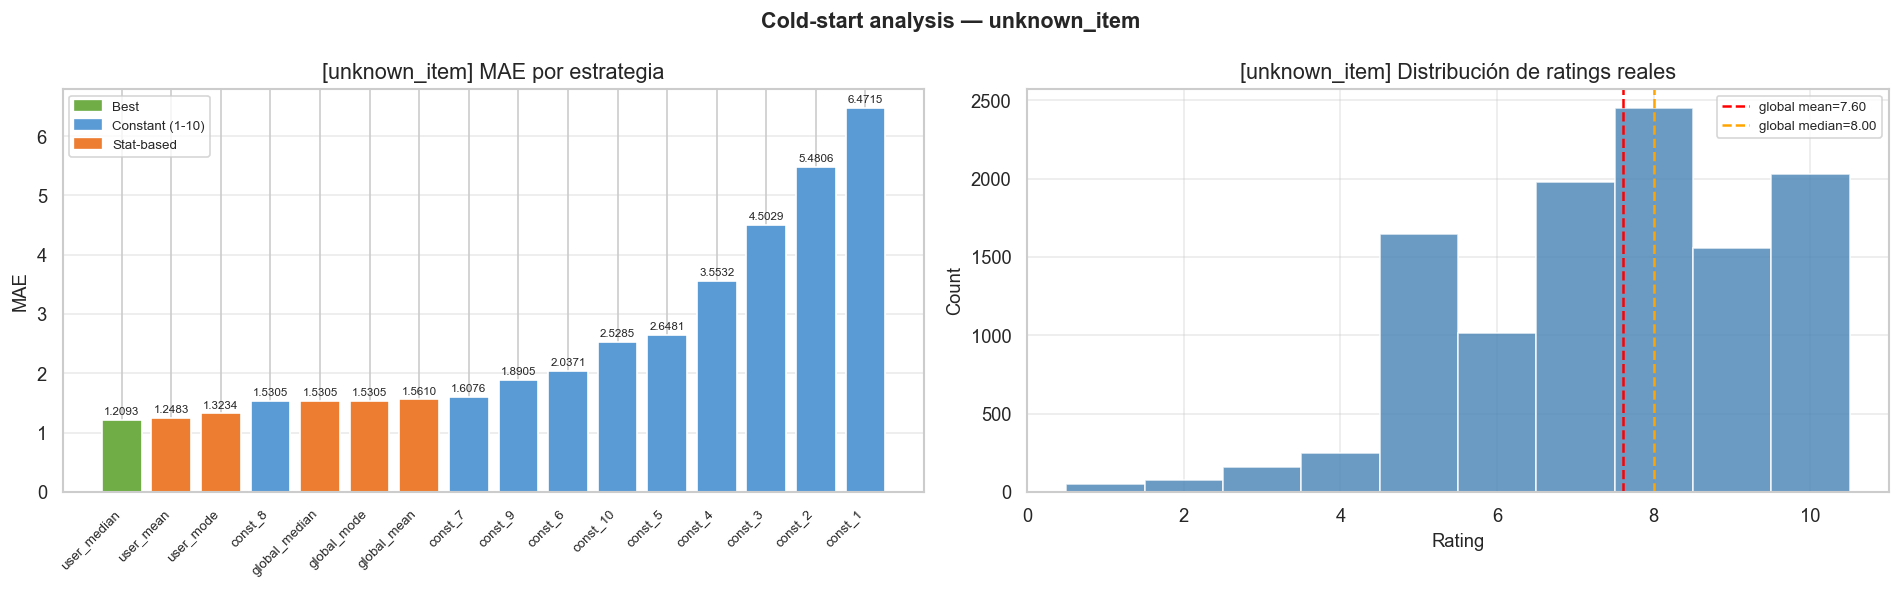


── both_unknown (n=1317) ──────────────────────────────
     strategy      mae
      const_7 1.589977
  global_mean 1.597782
      const_8 1.602885
global_median 1.602885
  global_mode 1.602885
      const_6 1.971906
      const_9 2.053151
      const_5 2.566439
     const_10 2.723614
      const_4 3.423690
      const_3 4.341686
      const_2 5.294609
      const_1 6.276386
  → Mejor estrategia: const_7 (MAE=1.5900)


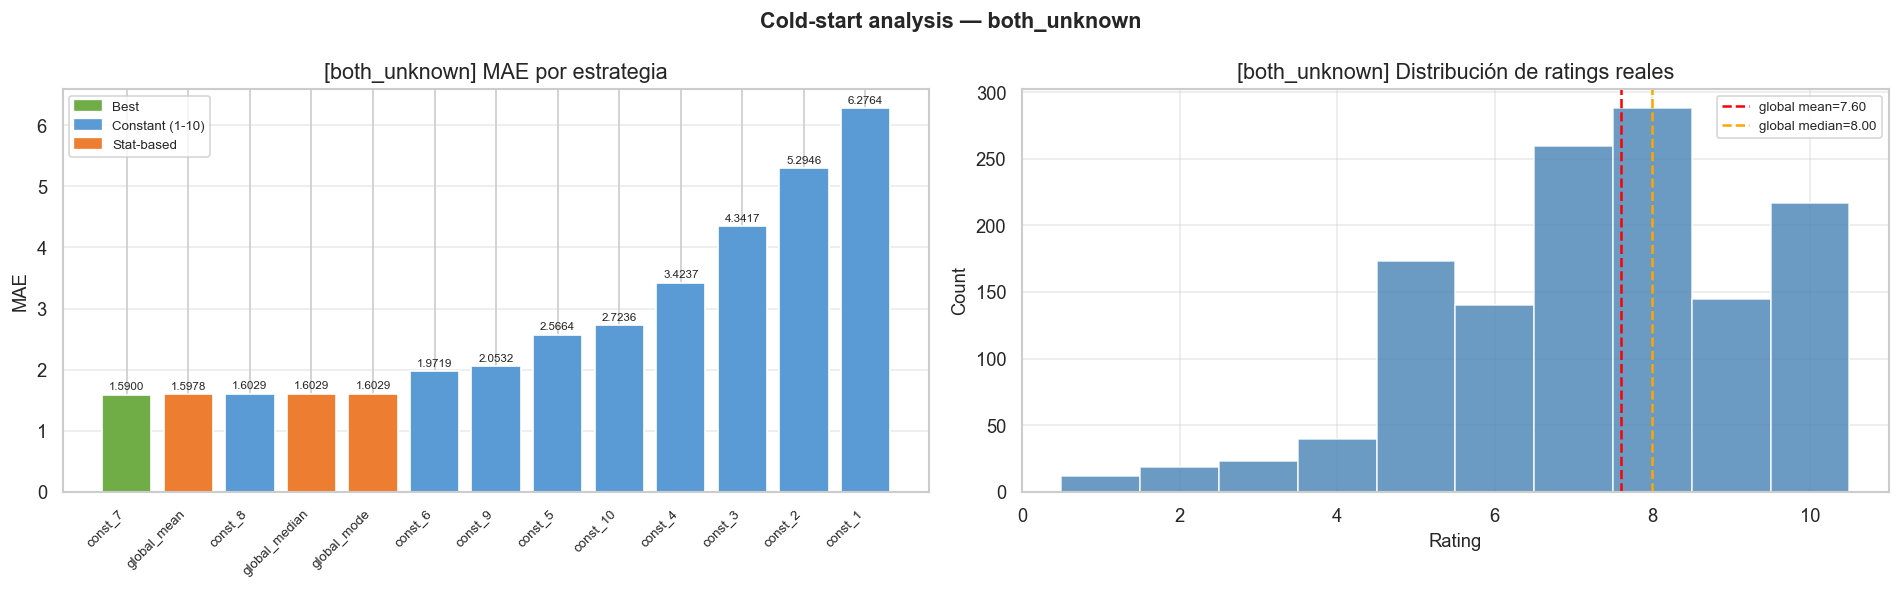

In [16]:
sparse_matrix, user_map, item_map = create_sparse_matrix(x_train, y_train)
best_strategies, user_stats, item_stats, global_mean_cs = analyze_coldstart(
    x_train, y_train, x_val, y_val, user_map, item_map
)


Mejores estrategias cold-start seleccionadas:
  unknown_user → const_8
  unknown_item → user_median
  both_unknown → const_7


Evaluating: 100%|██████████| 39036/39036 [01:08<00:00, 569.51it/s]


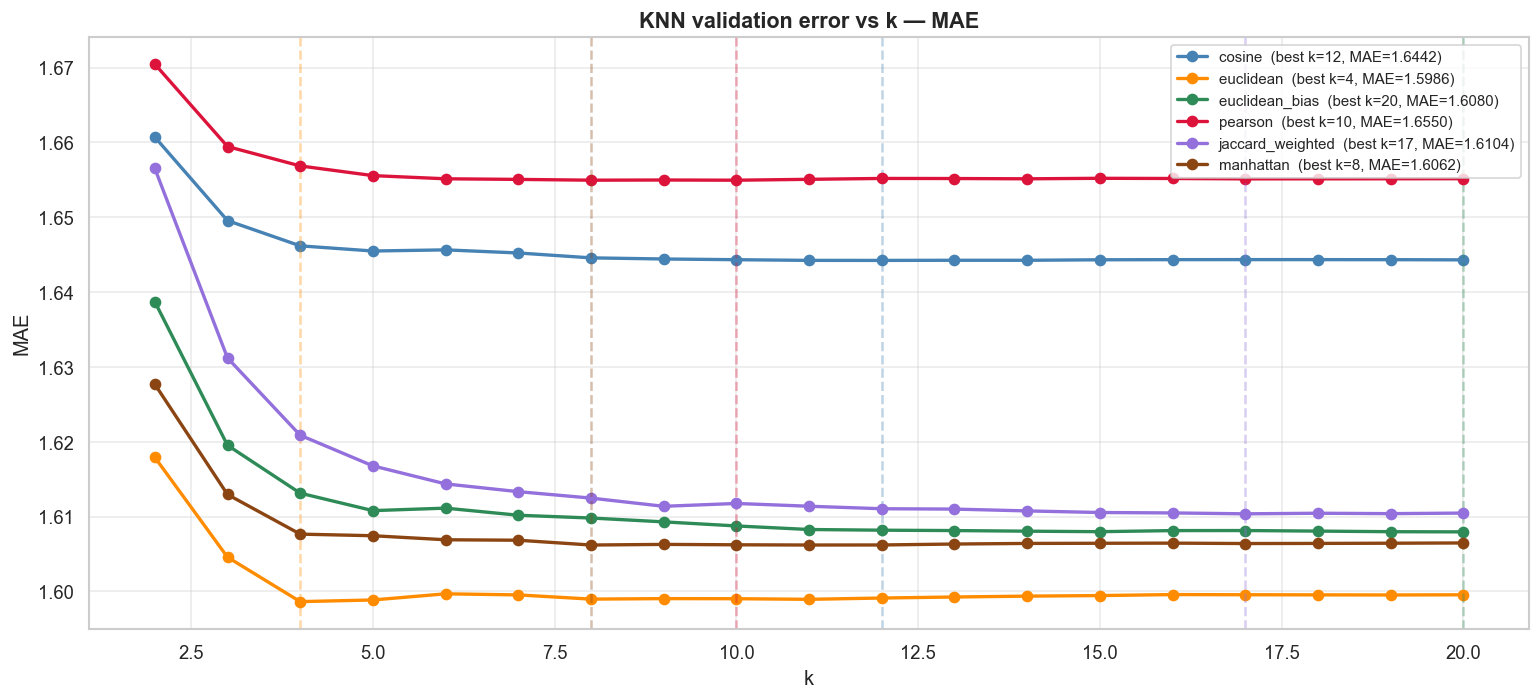


Mejor configuración KNN: metric='euclidean', k=4


Predicting: 100%|██████████| 43320/43320 [00:49<00:00, 869.02it/s] 


In [ ]:
best_cs_unknown_user = best_strategies.get('unknown_user', {}).get('strategy', 'global_mean')
best_cs_unknown_item = best_strategies.get('unknown_item', {}).get('strategy', 'global_mean')
best_cs_both         = best_strategies.get('both_unknown', {}).get('strategy', 'global_mean')

print("\nMejores estrategias cold-start seleccionadas:")
print(f"  unknown_user → {best_cs_unknown_user}")
print(f"  unknown_item → {best_cs_unknown_item}")
print(f"  both_unknown → {best_cs_both}")

user_means, item_means, global_mean = compute_stats(sparse_matrix)

results = evaluate_knn(
    x_val, y_val, sparse_matrix, user_map, item_map,
    k_max=20,
    metrics=['cosine', 'euclidean', 'euclidean_bias',
             'pearson', 'jaccard_weighted', 'manhattan'],
    error_metric='mae',
    cold_start={}
)

best_ks = plot_knn_error(results, error_metric='mae')
best_metric = min(best_ks, key=lambda m: np.nanmin(results['knn'][m][1]))
best_k      = best_ks[best_metric]
print(f"\nMejor configuración KNN: metric='{best_metric}', k={best_k}")

predictions = predict(
    df_test, sparse_matrix, user_map, item_map,
    user_means, item_means, global_mean,
    metric=best_metric,
    k=best_k,
    cold_start_unknown_user=best_cs_unknown_user,
    cold_start_unknown_item=best_cs_unknown_item,
    cold_start_both=best_cs_both,
)

predictions.to_csv('submission_knn.csv', index=False)

Como vemos en los resultados cuando no tenemos ni el usuario ni el ítem el mejor resultado lo obtenemos dando un rating de 7. Cuando solo tenemos el usuario, lo mejor es recomendar la mediana de recomendaciones de ese usuario en particular y cuando solo tenemos el ítem, tenemos que devolver el rating 8 nos da los mejores resultados.

Por otro lado, vemos como Jaccard obtiene los mejores resultados.

# NMF and BNMF

In [14]:
from bnmf import BNMF
from nmf import NMF

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9477    1.3629     1.8330     0.9274    1.3452     1.7875        ✔ best
     2     0.8789    1.2843     1.7489     0.8857    1.2972     1.7309        ✔ best
     3     0.8339    1.2325     1.6934     0.8635    1.2719     1.7007        ✔ best
     4     0.7989    1.1930     1.6489     0.8491    1.2567     1.6793        ✔ best
     5     0.7703    1.1606     1.6132     0.8388    1.2454     1.6651        ✔ best
     6     0.7458    1.1323     1.5824     0.8315    1.2374     1.6547        ✔ best
     7     0.7245    1.1080     1.5550     0.8261    1.2315     1.6463        ✔ best
     8     0.7055    1.0856     1.5313     0.8218    1.2268     1.6401        ✔ best
     9     0.6882    1.0657     1.5090     0.8182    1.2230     1.6345        ✔ best
    10     0.6726    1.0473     1.4890     0.8158    1.2205     

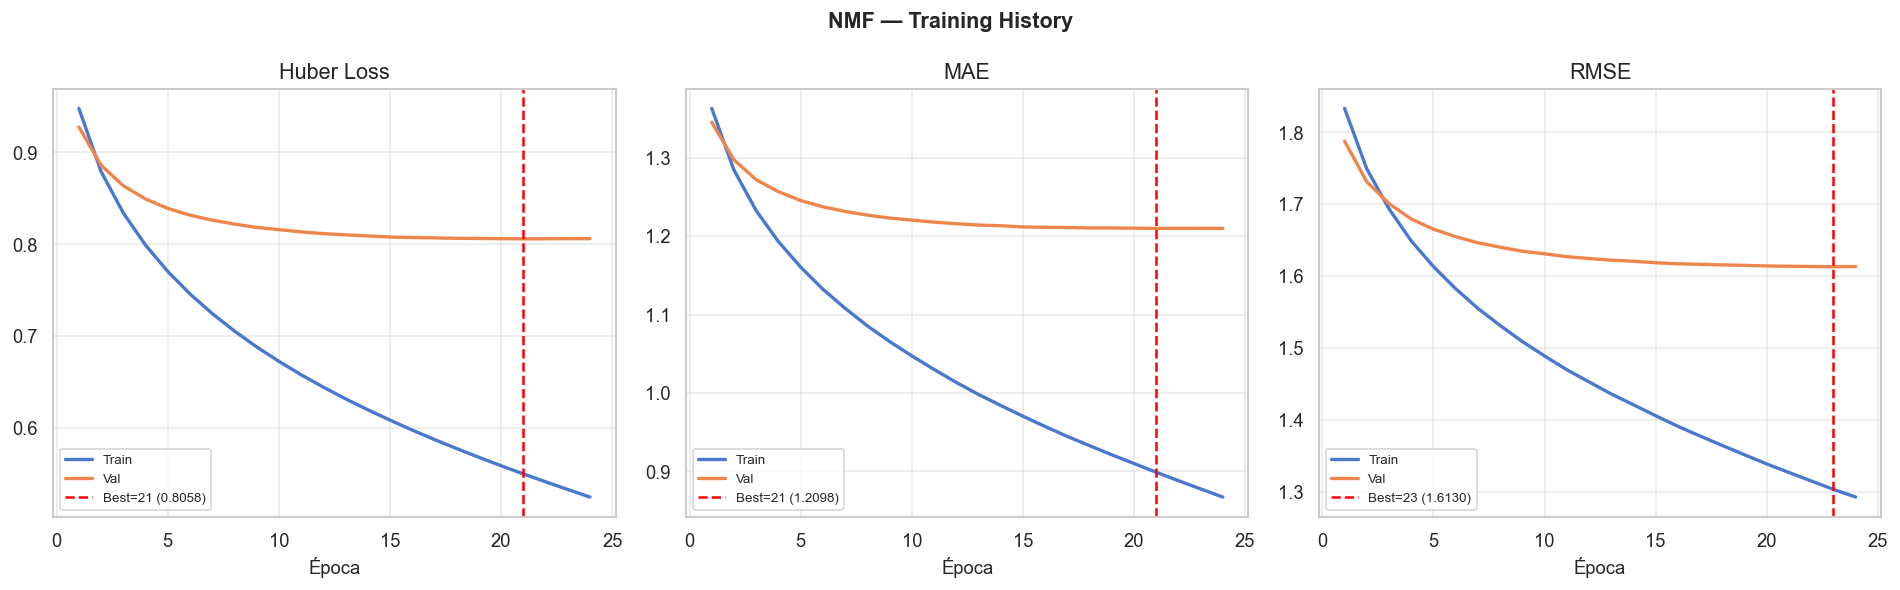

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE     SpU     SpV        Status
────────────────────────────────────────────────────────────────────────────────────────────────────
     1     0.9390    1.3522     1.8227     0.9302    1.3474     1.7892   2.44%   1.33%        ✔ best
     2     0.8626    1.2650     1.7303     0.8885    1.3000     1.7327   4.10%   2.34%        ✔ best
     3     0.8114    1.2062     1.6680     0.8663    1.2751     1.7026   5.50%   3.24%        ✔ best
     4     0.7715    1.1608     1.6181     0.8519    1.2599     1.6817   6.71%   4.04%        ✔ best
     5     0.7385    1.1227     1.5774     0.8416    1.2485     1.6675   7.81%   4.79%        ✔ best
     6     0.7101    1.0896     1.5421     0.8343    1.2407     1.6573   8.82%   5.50%        ✔ best
     7     0.6851    1.0605     1.5104     0.8287    1.2348     1.6488   9.70%   6.15%        ✔ best
     8     0.6625    1.0335     1.4824     0.8244    1.2301     1.6425  10.51%   6.77%     

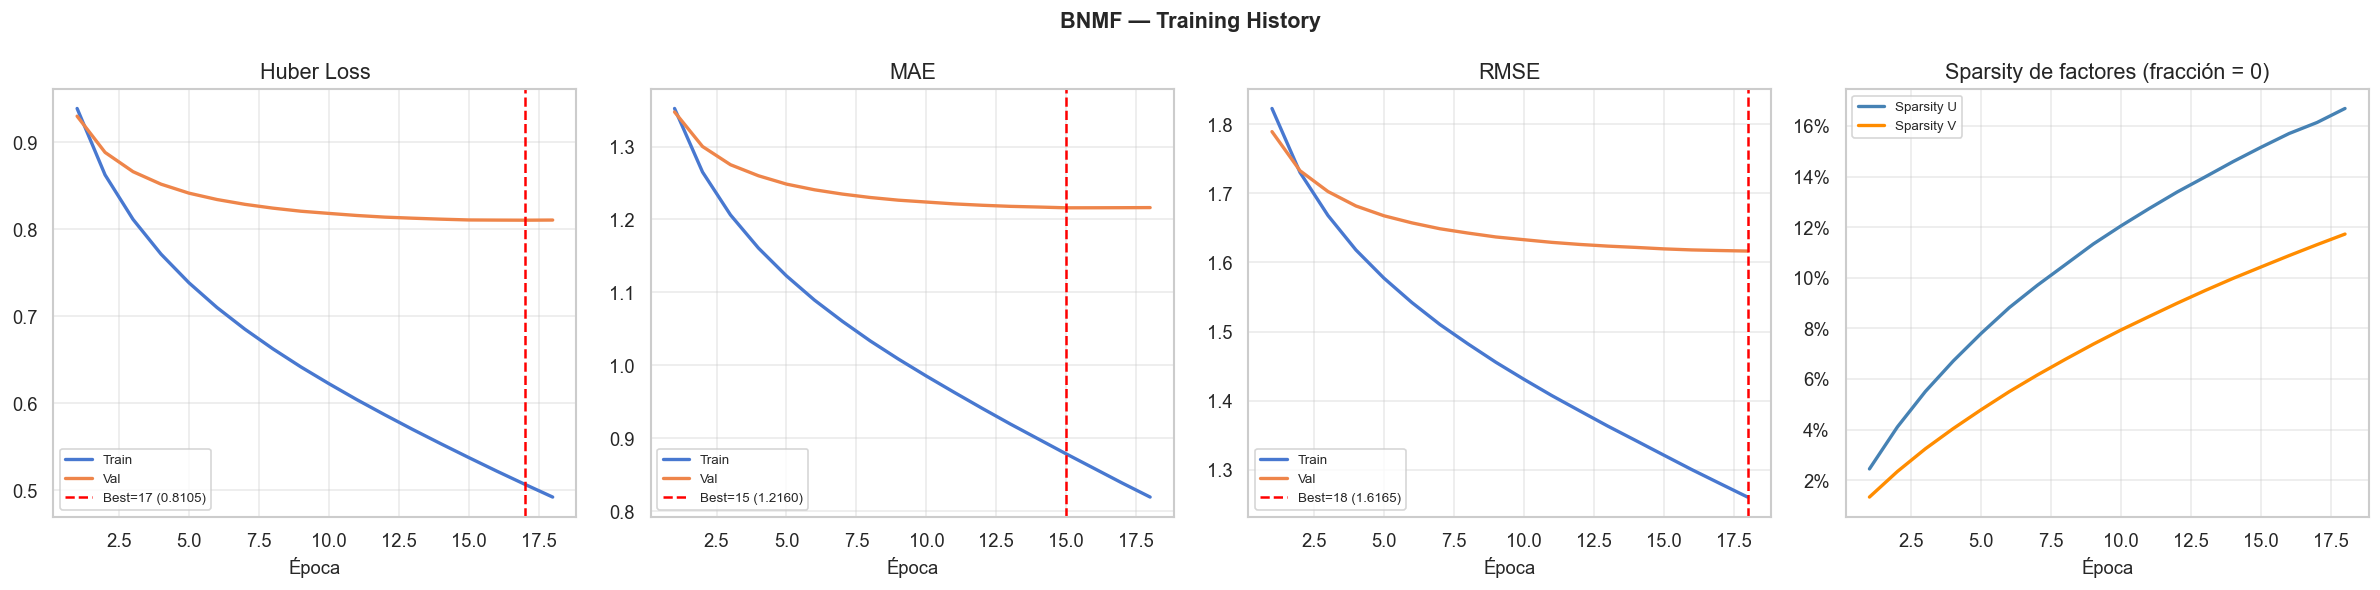

In [ ]:
base_params = dict(
    n_factors=200, lambda_bu=0.001, lambda_bi=0.001,
    lr=0.016, n_epochs=100, batch_size=256,
    optimizer='sgd', huber_delta=1.0,
    use_biases=True, log_every=1
)

nmf = NMF(**base_params, lambda_U=0.1, lambda_V=0.1)
nmf.fit(x_train, y_train, x_val, y_val, user_map, item_map, patience=3)
nmf.plot_loss()

bnmf = BNMF(**base_params, lambda_U=0.01, lambda_V=0.01)
bnmf.fit(x_train, y_train, x_val, y_val, user_map, item_map, patience=3)
bnmf.plot_loss()

# PMF y GridSearch de sus hiperparámetros

In [17]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [18]:
from pmf import PMF
from svdpp import SVDpp
from lightfm import LightFM

## Grid Search PMF — Resultados

**Nota**
No hemos podido recuperar la iteración para encontrar los mejores hiperparámetros por una cuestión de falta de tiempo. Añadimos la ejecución de estos modelos en el archivo ANEXO.ipynb.

| Grid | n_factors | lr | reg | reg_bias | Mejor val MAE |
|------|-----------|-----|-----|----------|--------------|
| 1 | 400–800 | 0.012–0.018 | 0.04–0.08 | 0.0005–0.002 | 1.4741 (BEST: f=800, lr=0.012, reg=0.08, rb=0.0005) |
| 2 | 800–1200 | 0.012–0.016 | 0.09–0.10 | 0.0005–0.002 | 1.4741 (BEST: f=800, lr=0.016, reg=0.10, rb=0.001) |
| 3 | 800–900 | 0.016–0.020 | 0.10–0.12 | 0.001–0.002 | 1.4740 (BEST: f=900, lr=0.02, reg=0.11, rb=0.0015) |
| 4 | 800 (fijo) | 0.014–0.017 | 0.09–0.105 | 0.0008–0.0012 | 1.4741 (BEST: f=800, lr=0.016, reg=0.105, rb=0.001) |
> Se ha marcado en negrita el resultado del modelo PMF que obtenía mejor puntuación en test púnlico. **Configuración adoptada:** `n_factors=800, lr=0.016, reg=0.105, reg_bias=0.001`  


## Ensemble PMF — Configuración óptima

9 modelos PMF con la config ganadora del grid search (`n_factors=800, lr=0.016, reg=0.10`),
seeds distintas para diversidad. Cold-start gestionado con estrategias óptimas de
`analyze_coldstart`. Val MAE resultante: **1.2316**.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm



def evaluate_predictions(preds, y_true, label=''):
    mae  = np.mean(np.abs(preds - y_true))
    rmse = np.sqrt(np.mean((preds - y_true) ** 2))
    print(f"{label:<30} MAE={mae:.4f}  RMSE={rmse:.4f}")
    return mae, rmse


def evaluate_disaggregated(preds, y_true, known_mask, label='Model'):
    print(f"\n── {label} ──────────────────────────────────────────")
    mae_total, rmse_total = evaluate_predictions(preds, y_true,
                                                  f"  Total      ({len(y_true):>5})")
    mae_k, _ = evaluate_predictions(preds[known_mask],  y_true[known_mask],
                                     f"  Conocidos  ({known_mask.sum():>5})")
    mae_c, _ = evaluate_predictions(preds[~known_mask], y_true[~known_mask],
                                     f"  Cold-start ({(~known_mask).sum():>5})")
    return {'total': mae_total, 'known': mae_k, 'cold': mae_c}



def retrain_full(x_train, y_train, x_val, y_val, pmf_params,
                 n_epochs_full=None, patience_val=10):
    print("═" * 60)
    print("STEP 1A — Encontrando épocas óptimas con train/val...")
    print("═" * 60)

    sparse_tv, user_map_tv, item_map_tv = create_sparse_matrix(x_train, y_train)
    user_means_tv, item_means_tv, global_mean_tv = compute_stats(sparse_tv)

    pmf_val = PMF(**pmf_params)
    pmf_val.fit(x_train, y_train, x_val, y_val,
                user_map_tv, item_map_tv, patience=patience_val)

    best_epoch = int(pd.DataFrame(pmf_val.history)['val_mae'].idxmin()) + 1
    print(f"\n→ Épocas óptimas encontradas: {best_epoch}")

    if n_epochs_full is not None:
        best_epoch = n_epochs_full
        print(f"→ Sobreescrito por n_epochs_full={n_epochs_full}")

    print("\n" + "═" * 60)
    print(f"STEP 1B — Reentrenando con train+val ({best_epoch} épocas)...")
    print("═" * 60)

    x_full = pd.concat([x_train, x_val]).reset_index(drop=True)
    y_full = pd.concat([y_train, y_val]).reset_index(drop=True)

    sparse_full, user_map_full, item_map_full = create_sparse_matrix(x_full, y_full)
    user_means_full, item_means_full, global_mean_full = compute_stats(sparse_full)

    full_params = {**pmf_params, 'n_epochs': best_epoch}
    pmf_full = PMF(**full_params)

    # val = train para que no rompa el código, patience=999 para no parar
    pmf_full.fit(x_full, y_full, x_full, y_full,
                 user_map_full, item_map_full, patience=999)

    print(f"\n✔ Modelo reentrenado con {len(x_full)} muestras")
    print(f"  Usuarios en train+val : {len(user_map_full)}")
    print(f"  Ítems en train+val    : {len(item_map_full)}")

    return (pmf_full, sparse_full, user_map_full, item_map_full,
            user_means_full, item_means_full, global_mean_full,
            pmf_val, sparse_tv, user_map_tv, item_map_tv,
            user_means_tv, item_means_tv, global_mean_tv)


def predict_pmf_with_bias_coldstart(pmf, x, user_map, item_map,
                                     clip_min=1.0, clip_max=10.0,
                                     has_id_col=False):
    ids, preds = [], []

    for _, row in tqdm(x.iterrows(), total=len(x), desc='Predicting PMF'):
        if has_id_col:
            row_id  = row.iloc[0]
            user_id = row.iloc[1]
            item_id = row.iloc[2]
            ids.append(row_id)
        else:
            user_id = row.iloc[0]
            item_id = row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        if u_known and i_known:
            u = user_map[user_id]
            i = item_map[item_id]
            p = pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i])

        elif u_known and not i_known:
            u = user_map[user_id]
            p = pmf.mu + pmf.b_u[u]

        elif not u_known and i_known:
            i = item_map[item_id]
            p = pmf.mu + pmf.b_i[i]

        else:
            p = pmf.mu

        preds.append(np.clip(p, clip_min, clip_max))

    if has_id_col:
        return pd.DataFrame({'id': ids, 'rating': preds})
    return np.array(preds)

def predict_knn_array(x_val, sparse_matrix, user_map, item_map,
                      user_means, item_means, global_mean,
                      metric='jaccard_weighted', k=5,
                      cold_start_unknown_user='global_mean',
                      cold_start_unknown_item='user_mean',
                      cold_start_both='const_7',
                      clip_min=1.0, clip_max=10.0):

    def _cold(strat, user_idx=None, item_idx=None):
        if strat == 'item_mean':
            v = item_means[item_idx] if item_idx is not None else np.nan
        elif strat == 'user_mean':
            v = user_means[user_idx] if user_idx is not None else np.nan
        elif strat == 'global_mean':
            v = global_mean
        elif strat.startswith('const_'):
            v = float(strat.split('_')[1])
        else:
            v = np.nan
        return global_mean if (isinstance(v, float) and np.isnan(v)) else v

    preds = []
    for _, row in tqdm(x_val.iterrows(), total=len(x_val), desc='Predicting KNN'):
        user_id = row.iloc[0]
        item_id = row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        if not u_known and not i_known:
            preds.append(_cold(cold_start_both))
            continue
        if not u_known:
            preds.append(_cold(cold_start_unknown_user, item_idx=item_map[item_id]))
            continue
        if not i_known:
            preds.append(_cold(cold_start_unknown_item, user_idx=user_map[user_id]))
            continue

        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        distances, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, [metric], user_means
        )
        distances = distances[metric]

        if len(distances) == 0:
            preds.append(_cold(cold_start_unknown_item, user_idx=user_idx))
            continue

        sorted_idx = np.argsort(distances)
        top_idx    = sorted_idx[:min(k, len(sorted_idx))]
        top_d      = distances[top_idx]
        top_r      = ratings[top_idx]
        weights    = 1 / (top_d + 1e-8)
        preds.append(np.clip(np.dot(weights, top_r) / weights.sum(), clip_min, clip_max))

    return np.array(preds)


def find_best_alpha(val_preds_pmf, val_preds_knn, y_val,
                    known_mask=None, clip_min=1.0, clip_max=10.0):
    mask  = known_mask if known_mask is not None else np.ones(len(y_val), dtype=bool)
    p_pmf = val_preds_pmf[mask]
    p_knn = val_preds_knn[mask]
    y     = y_val[mask]

    alphas, results = np.arange(0, 1.05, 0.05), []
    for alpha in alphas:
        blended = np.clip(alpha * p_pmf + (1 - alpha) * p_knn, clip_min, clip_max)
        mae     = np.mean(np.abs(blended - y))
        rmse    = np.sqrt(np.mean((blended - y) ** 2))
        results.append({'alpha': alpha, 'mae': mae, 'rmse': rmse})

    df      = pd.DataFrame(results)
    best    = df.loc[df['mae'].idxmin()]
    best_alpha = float(best['alpha'])

    print(f"\n{'Alpha':>7}  {'MAE':>8}  {'RMSE':>8}")
    print("─" * 30)
    for _, r in df.iterrows():
        marker = '  ✔ best' if r['alpha'] == best_alpha else ''
        print(f"{r['alpha']:>7.2f}  {r['mae']:>8.4f}  {r['rmse']:>8.4f}{marker}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, title in [(ax1, 'mae', 'MAE'), (ax2, 'rmse', 'RMSE')]:
        ax.plot(df['alpha'], df[metric], marker='o', linewidth=2)
        ax.axvline(best_alpha, color='red', linestyle='--',
                   label=f'Best α={best_alpha:.2f} ({best[metric]:.4f})')
        ax.axhline(np.mean(np.abs(p_pmf - y)) if metric == 'mae'
                   else np.sqrt(np.mean((p_pmf - y)**2)),
                   color='steelblue', linestyle=':', label='PMF solo')
        ax.axhline(np.mean(np.abs(p_knn - y)) if metric == 'mae'
                   else np.sqrt(np.mean((p_knn - y)**2)),
                   color='darkorange', linestyle=':', label='KNN solo')
        ax.set_xlabel('Alpha  (0=KNN, 1=PMF)')
        ax.set_ylabel(title)
        ax.set_title(f'Ensemble — {title}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.4)
    suffix = f'sobre conocidos ({mask.sum()})' if known_mask is not None else 'total'
    fig.suptitle(f'PMF + KNN Ensemble ({suffix})', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    return best_alpha


def ensemble_test(pmf_full, x_test,
                  sparse_tv, user_map_tv, item_map_tv,
                  user_means_tv, item_means_tv, global_mean_tv,
                  user_map_full, item_map_full,
                  best_alpha, k, metric='jaccard_weighted',
                  clip_min=1.0, clip_max=10.0):

    print("Generando predicciones PMF (train+val)...")
    x_test_noid = x_test.iloc[:, 1:]   # quitar columna id
    preds_pmf   = predict_pmf_with_bias_coldstart(
        pmf_full, x_test_noid, user_map_full, item_map_full,
        clip_min=clip_min, clip_max=clip_max, has_id_col=False
    )

    print("Generando predicciones KNN (train only)...")
    preds_knn = predict_knn_array(
        x_test_noid, sparse_tv, user_map_tv, item_map_tv,
        user_means_tv, item_means_tv, global_mean_tv,
        metric=metric, k=k, clip_min=clip_min, clip_max=clip_max
    )

    blended = np.clip(best_alpha * preds_pmf + (1 - best_alpha) * preds_knn,
                      clip_min, clip_max)

    submission = pd.DataFrame({'id': x_test.iloc[:, 0].values, 'rating': blended})
    return submission

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
from collections import Counter

def _cold_pred_from_strategy(strategy_name, user_id, item_id,
                              user_stats, item_stats, global_mean):
    if strategy_name.startswith('const_'):
        return float(strategy_name.split('_')[1])
    if strategy_name == 'global_mean':
        return global_mean
    if strategy_name == 'item_mean':
        return item_stats.loc[item_id, 'mean'] if item_id in item_stats.index else global_mean
    if strategy_name == 'item_median':
        return item_stats.loc[item_id, 'median'] if item_id in item_stats.index else global_mean
    if strategy_name == 'item_mode':
        return item_stats.loc[item_id, 'mode'] if item_id in item_stats.index else global_mean
    if strategy_name == 'user_mean':
        return user_stats.loc[user_id, 'mean'] if user_id in user_stats.index else global_mean
    if strategy_name == 'user_median':
        return user_stats.loc[user_id, 'median'] if user_id in user_stats.index else global_mean
    if strategy_name == 'user_mode':
        return user_stats.loc[user_id, 'mode'] if user_id in user_stats.index else global_mean
    return global_mean


def predict_pmf_real_mae(pmf, x_val, y_val, user_map, item_map,
                         best_strategies, user_stats, item_stats, global_mean,
                         clip_min=1.0, clip_max=10.0):
    cs_unknown_user = best_strategies['unknown_user']['strategy']
    cs_unknown_item = best_strategies['unknown_item']['strategy']
    cs_both         = best_strategies['both_unknown']['strategy']

    preds = []
    for _, row in x_val.iterrows():
        user_id = row.iloc[0]
        item_id = row.iloc[1]
        u_known = user_id in user_map
        i_known = item_id in item_map

        if not u_known and not i_known:
            p = _cold_pred_from_strategy(cs_both, user_id, item_id,
                                          user_stats, item_stats, global_mean)
        elif not u_known:
            p = _cold_pred_from_strategy(cs_unknown_user, user_id, item_id,
                                          user_stats, item_stats, global_mean)
        elif not i_known:
            p = _cold_pred_from_strategy(cs_unknown_item, user_id, item_id,
                                          user_stats, item_stats, global_mean)
        else:
            u = user_map[user_id]
            i = item_map[item_id]
            p = pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i])
            p = float(np.clip(p, clip_min, clip_max))

        preds.append(p)

    preds    = np.array(preds)
    real_mae = float(np.mean(np.abs(preds - y_val.values)))
    return preds, real_mae


def train_pmf_ensemble(x_train, y_train, x_val, y_val,
                       user_map, item_map,
                       best_strategies, user_stats, item_stats, global_mean,
                       pmf_params, n_models=5, seeds=None,
                       clip_min=1.0, clip_max=10.0):
    if seeds is None:
        seeds = list(range(n_models))

    ensemble_info = []

    for idx, seed in enumerate(seeds):
        print(f"\n{'═'*60}")
        print(f"  Modelo {idx+1}/{n_models}  —  seed={seed}")
        print(f"{'═'*60}")

        params = {**pmf_params, 'random_state': seed}
        pmf    = PMF(**params)
        pmf.fit(x_train, y_train, x_val, y_val,
                user_map, item_map,
                patience=3)

        stop_epoch = len(pmf.history)
        val_preds, real_mae = predict_pmf_real_mae(
            pmf, x_val, y_val, user_map, item_map,
            best_strategies, user_stats, item_stats, global_mean,
            clip_min, clip_max
        )

        print(f"\n  → Stop epoch : {stop_epoch}")
        print(f"  → MAE real   : {real_mae:.4f}")

        ensemble_info.append({
            'seed'       : seed,
            'model'      : pmf,
            'stop_epoch' : stop_epoch,
            'real_mae'   : real_mae,
            'val_preds'  : val_preds,
        })

    return ensemble_info

def weighted_predict(models_info, x, user_map, item_map,
                     best_strategies, user_stats, item_stats, global_mean,
                     clip_min=1.0, clip_max=10.0, has_id_col=False):

    maes    = np.array([m['real_mae'] for m in models_info])
    weights = 1 / maes
    weights = weights / weights.sum() 

    print(f"\nPesos del ensemble:")
    for info, w in zip(models_info, weights):
        print(f"  seed={info['seed']}  MAE={info['real_mae']:.4f}  peso={w:.4f}")

    cs_unknown_user = best_strategies['unknown_user']['strategy']
    cs_unknown_item = best_strategies['unknown_item']['strategy']
    cs_both         = best_strategies['both_unknown']['strategy']

    ids_out, preds_out = [], []

    for _, row in tqdm(x.iterrows(), total=len(x), desc='Weighted predict'):
        if has_id_col:
            row_id  = row.iloc[0]
            user_id = row.iloc[1]
            item_id = row.iloc[2]
            ids_out.append(row_id)
        else:
            user_id = row.iloc[0]
            item_id = row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        if not u_known and not i_known:
            p = _cold_pred_from_strategy(cs_both, user_id, item_id,
                                          user_stats, item_stats, global_mean)
            preds_out.append(p)
            continue

        if not u_known:
            p = _cold_pred_from_strategy(cs_unknown_user, user_id, item_id,
                                          user_stats, item_stats, global_mean)
            preds_out.append(p)
            continue

        if not i_known:
            p = _cold_pred_from_strategy(cs_unknown_item, user_id, item_id,
                                          user_stats, item_stats, global_mean)
            preds_out.append(p)
            continue

        model_preds = []
        for info in models_info:
            pmf = info['model']
            u   = user_map[user_id]
            i   = item_map[item_id]
            p   = pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i])
            model_preds.append(np.clip(p, clip_min, clip_max))

        p_final = float(np.dot(weights, model_preds))
        preds_out.append(np.clip(p_final, clip_min, clip_max))

    if has_id_col:
        return pd.DataFrame({'ID': ids_out, 'rating': preds_out})
    return np.array(preds_out)

def train_full_ensemble(x_train, y_train, x_val, y_val,
                        ensemble_info, pmf_params,
                        best_strategies, user_stats, item_stats,
                        n_models=5, seeds=None,
                        clip_min=1.0, clip_max=10.0):
    mean_epochs = int(np.round(np.mean([m['stop_epoch'] for m in ensemble_info])))
    print(f"\nÉpocas de parada por modelo: {[m['stop_epoch'] for m in ensemble_info]}")
    print(f"Media de épocas → {mean_epochs}")

    x_full = pd.concat([x_train, x_val]).reset_index(drop=True)
    y_full = pd.concat([y_train, y_val]).reset_index(drop=True)

    sparse_full, user_map_full, item_map_full = create_sparse_matrix(x_full, y_full)
    user_means_full, item_means_full, global_mean_full = compute_stats(sparse_full)

    if seeds is None:
        seeds = [m['seed'] for m in ensemble_info]

    full_params = {**pmf_params, 'n_epochs': mean_epochs}
    full_ensemble_info = []

    for idx, seed in enumerate(seeds):
        print(f"\n{'═'*60}")
        print(f"  Modelo FULL {idx+1}/{n_models}  —  seed={seed}  epochs={mean_epochs}")
        print(f"{'═'*60}")

        params = {**full_params, 'random_state': seed}
        pmf    = PMF(**params)

        # val = train (sin early stopping real, épocas fijas)
        pmf.fit(x_full, y_full, x_full, y_full,
                user_map_full, item_map_full, patience=999)

        full_ensemble_info.append({
            'seed'  : seed,
            'model' : pmf,
            # MAE del modelo equivalente en val para mantener los pesos
            'real_mae' : ensemble_info[idx]['real_mae'],
        })

    return full_ensemble_info, user_map_full, item_map_full, global_mean_full

def plot_ensemble_summary(ensemble_info):
    seeds       = [m['seed']       for m in ensemble_info]
    maes        = [m['real_mae']   for m in ensemble_info]
    stop_epochs = [m['stop_epoch'] for m in ensemble_info]
    weights     = 1 / np.array(maes); weights /= weights.sum()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # MAE por modelo
    colors = ['#70ad47' if m == min(maes) else '#5b9bd5' for m in maes]
    axes[0].bar([f'seed={s}' for s in seeds], maes, color=colors, edgecolor='white')
    axes[0].set_title('MAE real por modelo')
    axes[0].set_ylabel('MAE')
    axes[0].grid(True, axis='y', alpha=0.4)
    for i, v in enumerate(maes):
        axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

    # Pesos
    axes[1].bar([f'seed={s}' for s in seeds], weights, color='#ed7d31', edgecolor='white')
    axes[1].set_title('Pesos ensemble (1/MAE normalizado)')
    axes[1].set_ylabel('Peso')
    axes[1].grid(True, axis='y', alpha=0.4)
    for i, v in enumerate(weights):
        axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

    # Épocas de parada
    axes[2].bar([f'seed={s}' for s in seeds], stop_epochs, color='#9b59b6', edgecolor='white')
    axes[2].axhline(np.mean(stop_epochs), color='red', linestyle='--',
                    label=f'Media={np.mean(stop_epochs):.1f}')
    axes[2].set_title('Época de parada por modelo')
    axes[2].set_ylabel('Época')
    axes[2].legend(); axes[2].grid(True, axis='y', alpha=0.4)

    fig.suptitle('PMF Ensemble — Resumen', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

In [14]:
# {'n_factors': 800, 'lr': 0.016, 'reg': 0.1, 'reg_bias': 0.001}
pmf_params = dict(
    n_factors   = 800,
    lambda_U    = 0.1,  lambda_V  = 0.1,
    lambda_bu   = 0.001, lambda_bi = 0.001,
    lr          = 0.016, n_epochs = 200,
    batch_size  = 256, optimizer = 'sgd',
    use_biases  = True, huber_delta = 1.0,
    log_every   = 5
)
ensemble_info = train_pmf_ensemble(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    pmf_params, n_models=9,
    seeds=[42, 7, 123, 999, 202,91,88816,527,6]
)


════════════════════════════════════════════════════════════
  Modelo 1/9  —  seed=42
════════════════════════════════════════════════════════════
 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     5     0.7142    1.1004     1.5032     0.8221    1.2295     1.6173        ✔ best
    10     0.5935    0.9587     1.3605     0.8015    1.2065     1.5971        ✔ best
    15     0.4911    0.8345     1.2297     0.7942    1.1990     1.5891        ✔ best
    20     0.3915    0.7096     1.0906     0.7922    1.1973     1.5850        ✔ best
    25     0.2983    0.5846     0.9477     0.7923    1.1976     1.5826    no imp 1/3

Early stopping época 27 | best val MAE: 1.1970

  → Stop epoch : 27
  → MAE real   : 1.2282

════════════════════════════════════════════════════════════
  Modelo 2/9  —  seed=7
════════════════════════════════════════════════════════════
 Epoch   Tr Hube

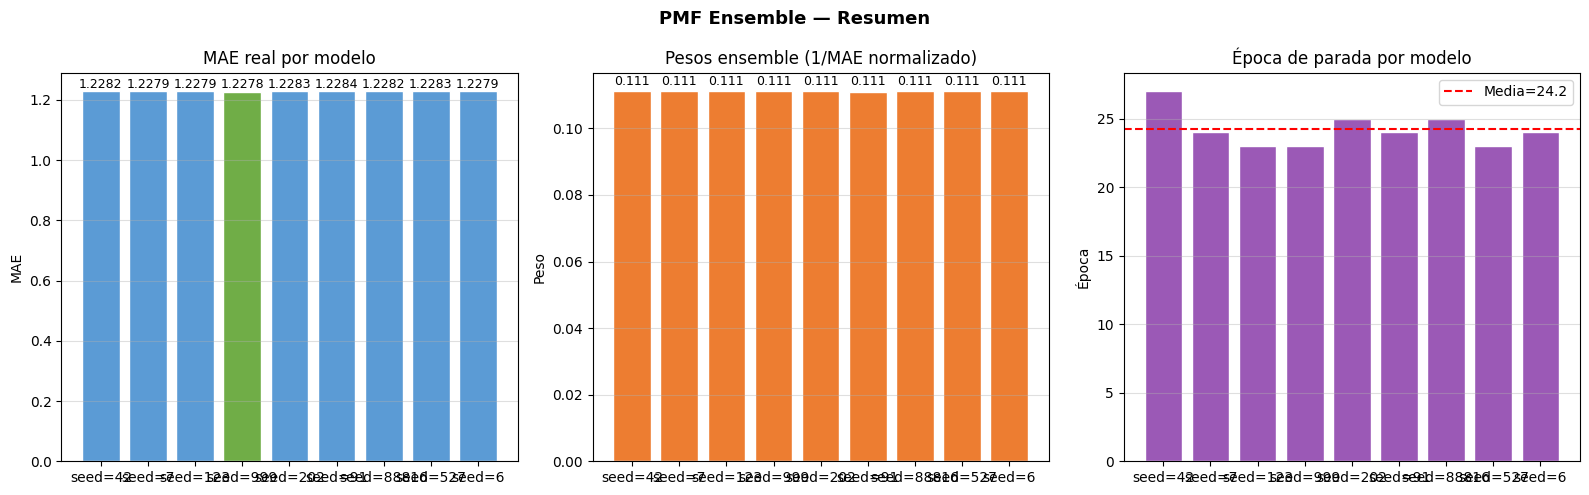

In [17]:
plot_ensemble_summary(ensemble_info)

In [65]:
val_preds_ensemble = weighted_predict(
    ensemble_info, x_val, user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    has_id_col=False
)
mae_ensemble = np.mean(np.abs(val_preds_ensemble - y_val.values))
print(f"\nMAE ensemble (val): {mae_ensemble:.4f}")


Pesos del ensemble:
  seed=42  MAE=1.2315  peso=0.2000
  seed=7  MAE=1.2316  peso=0.2000
  seed=123  MAE=1.2318  peso=0.2000
  seed=999  MAE=1.2317  peso=0.2000
  seed=2024  MAE=1.2317  peso=0.2000


Weighted predict: 100%|██████████| 39036/39036 [00:01<00:00, 19650.63it/s]


MAE ensemble (val): 1.2316


In [18]:
file_test = "data/test.csv"
df_test = pd.read_csv(file_test, header=0)
test_preds_ensemble = weighted_predict(
    ensemble_info, df_test, user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    has_id_col=True
)


Pesos del ensemble:
  seed=42  MAE=1.2282  peso=0.1111
  seed=7  MAE=1.2279  peso=0.1111
  seed=123  MAE=1.2279  peso=0.1111
  seed=999  MAE=1.2278  peso=0.1111
  seed=202  MAE=1.2283  peso=0.1111
  seed=91  MAE=1.2284  peso=0.1111
  seed=88816  MAE=1.2282  peso=0.1111
  seed=527  MAE=1.2283  peso=0.1111
  seed=6  MAE=1.2279  peso=0.1111


Weighted predict: 100%|██████████| 43320/43320 [00:17<00:00, 2432.92it/s]


In [ ]:
test_preds_ensemble.to_csv('submission_ensemble_pmf.csv', index=False)


In [ ]:
full_ensemble_info, user_map_full, item_map_full, global_mean_full = train_full_ensemble(
    x_train, y_train, x_val, y_val,
    ensemble_info, pmf_params,
    best_strategies, user_stats, item_stats,
    seeds=[42, 7, 123, 999, 202,91,88816,527,6]
)

submission = weighted_predict(
    full_ensemble_info, df_test, user_map_full, item_map_full,
    best_strategies, user_stats, item_stats, global_mean_full,
    has_id_col=True
)
submission.to_csv('submission_ensemble_pmf2_full.csv', index=False)
print(f"\nSubmission guardado: {len(submission)} predicciones")


Épocas de parada por modelo: [27, 24, 23, 23, 25, 24, 25, 23, 24]
Media de épocas → 24

════════════════════════════════════════════════════════════
  Modelo FULL 1/5  —  seed=42  epochs=24
════════════════════════════════════════════════════════════
 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     5     0.7130    1.0993     1.5021     0.7130    1.0993     1.5021        ✔ best
    10     0.5952    0.9611     1.3627     0.5952    0.9611     1.3627        ✔ best
    15     0.4949    0.8395     1.2348     0.4949    0.8395     1.2348        ✔ best
    20     0.3963    0.7157     1.0978     0.3963    0.7157     1.0978        ✔ best

════════════════════════════════════════════════════════════
  Modelo FULL 2/5  —  seed=7  epochs=24
════════════════════════════════════════════════════════════
 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE    

NameError: name 'x_test' is not defined

In [30]:
submission = weighted_predict(
    full_ensemble_info, df_test, user_map_full, item_map_full,
    best_strategies, user_stats, item_stats, global_mean_full,
    has_id_col=True
)
submission.to_csv('submission_ensemble_pmf2_full.csv', index=False)
print(f"\nSubmission guardado: {len(submission)} predicciones")


Pesos del ensemble:
  seed=42  MAE=1.2282  peso=0.1111
  seed=7  MAE=1.2279  peso=0.1111
  seed=123  MAE=1.2279  peso=0.1111
  seed=999  MAE=1.2278  peso=0.1111
  seed=202  MAE=1.2283  peso=0.1111
  seed=91  MAE=1.2284  peso=0.1111
  seed=88816  MAE=1.2282  peso=0.1111
  seed=527  MAE=1.2283  peso=0.1111
  seed=6  MAE=1.2279  peso=0.1111


Weighted predict:  18%|█▊        | 7894/43320 [00:03<00:16, 2134.62it/s]


KeyboardInterrupt: 

# LightFM — Exploración Individual

| Config | n_factors | λ_U=λ_V | λ_bias | lr | Best val MAE |
|--------|-----------|---------|--------|----|-------------|
| 1 | 800 | 0.500 | 0.002 | 0.016 | ∼1.2338 |
| 2 | 800 | 0.175 | 0.001 | 0.016 | ∼1.2350 |
| 3 | 1200 | 0.500 | 0.010 | 0.016 | ∼1.2601 |
| **4** | **1200** | **0.500** | **0.005** | **0.020** | **1.1963 ✓** |
| 5 | 1200 | 0.600 | 0.0075 | 0.020 | 1.1964 |
| 6 | 1200 | 0.800 | 0.0075 | 0.020 | 1.1964 |
| 7 | 1200 | 1.000 | 0.0075 | 0.020 | 1.1965 |


In [ ]:
from lightfm import LightFM
model = LightFM(n_factors=800, lambda_U=0.5, lambda_V=0.5,
                 lambda_bu=0.002, lambda_bi=0.002,
                 lr=0.016, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)   # ← nuevo kwarg opcional

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8954    1.3120     1.6903     0.9296    1.3515     1.7308        ✔ best
     2     0.8390    1.2459     1.6350     0.8970    1.3127     1.7031        ✔ best
     3     0.8014    1.2021     1.5970     0.8791    1.2915     1.6883        ✔ best
     4     0.7724    1.1686     1.5662     0.8674    1.2778     1.6779        ✔ best
     5     0.7484    1.1405     1.5405     0.8590    1.2676     1.6707        ✔ best
     6     0.7278    1.1166     1.5177     0.8528    1.2603     1.6649        ✔ best
     7     0.7098    1.0956     1.4972     0.8481    1.2548     1.6604        ✔ best
     8     0.6936    1.0768     1.4793     0.8443    1.2504     1.6570        ✔ best
     9     0.6789    1.0595     1.4627     0.8412    1.2466     1.6543        ✔ best
    10     0.6656    1.0439     1.4469     0.8389    1.2439     

KeyboardInterrupt: 

In [ ]:
from lightfm import LightFM
model = LightFM(n_factors=800, lambda_U=0.175, lambda_V=0.175,
                 lambda_bu=0.001, lambda_bi=0.001,
                 lr=0.016, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None) 

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8924    1.3084     1.6872     0.9296    1.3515     1.7309        ✔ best
     2     0.8315    1.2372     1.6268     0.8971    1.3128     1.7032        ✔ best
     3     0.7894    1.1881     1.5836     0.8792    1.2917     1.6883        ✔ best
     4     0.7557    1.1493     1.5473     0.8676    1.2781     1.6779        ✔ best
     5     0.7272    1.1158     1.5161     0.8593    1.2680     1.6706        ✔ best
     6     0.7021    1.0866     1.4877     0.8532    1.2608     1.6649        ✔ best
     7     0.6796    1.0603     1.4617     0.8485    1.2554     1.6602        ✔ best
     8     0.6589    1.0362     1.4381     0.8447    1.2511     1.6568        ✔ best
     9     0.6398    1.0135     1.4158     0.8417    1.2474     1.6539        ✔ best
    10     0.6220    0.9925     1.3942     0.8393    1.2448     

KeyboardInterrupt: 

In [ ]:
from lightfm import LightFM
model = LightFM(n_factors=1200, lambda_U=0.5, lambda_V=0.5,
                 lambda_bu=0.01, lambda_bi=0.01,
                 lr=0.016, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8954    1.3120     1.6903     0.9294    1.3513     1.7305        ✔ best
     2     0.8390    1.2459     1.6350     0.8968    1.3125     1.7029        ✔ best
     3     0.8014    1.2021     1.5971     0.8789    1.2913     1.6881        ✔ best
     4     0.7724    1.1686     1.5662     0.8672    1.2777     1.6778        ✔ best
     5     0.7484    1.1404     1.5406     0.8589    1.2674     1.6706        ✔ best
     6     0.7278    1.1165     1.5177     0.8527    1.2601     1.6649        ✔ best


KeyboardInterrupt: 

In [ ]:
from lightfm import LightFM
model = LightFM(n_factors=1200, lambda_U=0.5, lambda_V=0.5,
                 lambda_bu=0.005, lambda_bi=0.005,
                 lr=0.02, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8733    1.2856     1.6706     0.8874    1.3056     1.6749        ✔ best
     2     0.8148    1.2175     1.6125     0.8522    1.2646     1.6441        ✔ best
     3     0.7764    1.1726     1.5731     0.8336    1.2426     1.6284        ✔ best
     4     0.7467    1.1384     1.5403     0.8218    1.2291     1.6171        ✔ best
     5     0.7223    1.1101     1.5135     0.8137    1.2197     1.6100        ✔ best
     6     0.7015    1.0857     1.4898     0.8081    1.2133     1.6049        ✔ best
     7     0.6832    1.0647     1.4687     0.8039    1.2086     1.6007        ✔ best
     8     0.6670    1.0455     1.4502     0.8008    1.2052     1.5981        ✔ best
     9     0.6522    1.0287     1.4326     0.7982    1.2024     1.5954        ✔ best
    10     0.6389    1.0129     1.4170     0.7968    1.2008     

KeyboardInterrupt: 

In [ ]:
from lightfm import LightFM
model = LightFM(n_factors=1200, lambda_U=0.6, lambda_V=0.6,
                 lambda_bu=0.0075, lambda_bi=0.0075,
                 lr=0.02, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8743    1.2868     1.6716     0.8875    1.3057     1.6749        ✔ best
     2     0.8167    1.2198     1.6145     0.8522    1.2648     1.6440        ✔ best
     3     0.7792    1.1759     1.5760     0.8337    1.2427     1.6283        ✔ best
     4     0.7501    1.1425     1.5441     0.8218    1.2292     1.6170        ✔ best
     5     0.7264    1.1151     1.5181     0.8137    1.2198     1.6099        ✔ best
     6     0.7061    1.0913     1.4952     0.8081    1.2134     1.6048        ✔ best
     7     0.6885    1.0710     1.4747     0.8039    1.2087     1.6006        ✔ best
     8     0.6727    1.0524     1.4568     0.8008    1.2053     1.5980        ✔ best
     9     0.6584    1.0361     1.4399     0.7982    1.2025     1.5953        ✔ best
    10     0.6455    1.0209     1.4248     0.7968    1.2009     

In [ ]:
from lightfm import LightFM

model = LightFM(n_factors=1200, lambda_U=0.8, lambda_V=0.8,
                 lambda_bu=0.0075, lambda_bi=0.0075,
                 lr=0.02, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8757    1.2885     1.6731     0.8875    1.3057     1.6749        ✔ best
     2     0.8195    1.2230     1.6177     0.8522    1.2647     1.6440        ✔ best
     3     0.7831    1.1805     1.5805     0.8336    1.2426     1.6283        ✔ best
     4     0.7551    1.1482     1.5498     0.8217    1.2291     1.6170        ✔ best
     5     0.7323    1.1218     1.5249     0.8136    1.2197     1.6099        ✔ best
     6     0.7128    1.0990     1.5030     0.8080    1.2133     1.6048        ✔ best
     7     0.6958    1.0795     1.4834     0.8038    1.2086     1.6006        ✔ best
     8     0.6806    1.0617     1.4663     0.8008    1.2052     1.5981        ✔ best
     9     0.6669    1.0460     1.4501     0.7982    1.2024     1.5954        ✔ best
    10     0.6545    1.0314     1.4356     0.7968    1.2008     

In [ ]:
from lightfm import LightFM
model = LightFM(n_factors=1200, lambda_U=1, lambda_V=1,
                 lambda_bu=0.0075, lambda_bi=0.0075,
                 lr=0.02, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True)
model.fit(x_train, y_train, x_val, y_val,
          user_map, item_map,
          item_features=None)

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8768    1.2897     1.6743     0.8875    1.3057     1.6749        ✔ best
     2     0.8216    1.2254     1.6200     0.8522    1.2647     1.6440        ✔ best
     3     0.7860    1.1838     1.5838     0.8336    1.2426     1.6283        ✔ best
     4     0.7586    1.1524     1.5540     0.8217    1.2291     1.6170        ✔ best
     5     0.7364    1.1266     1.5298     0.8136    1.2196     1.6099        ✔ best
     6     0.7174    1.1043     1.5084     0.8080    1.2132     1.6048        ✔ best
     7     0.7008    1.0854     1.4894     0.8038    1.2085     1.6006        ✔ best
     8     0.6860    1.0679     1.4728     0.8007    1.2051     1.5981        ✔ best
     9     0.6726    1.0527     1.4569     0.7981    1.2023     1.5954        ✔ best
    10     0.6604    1.0384     1.4428     0.7968    1.2007     

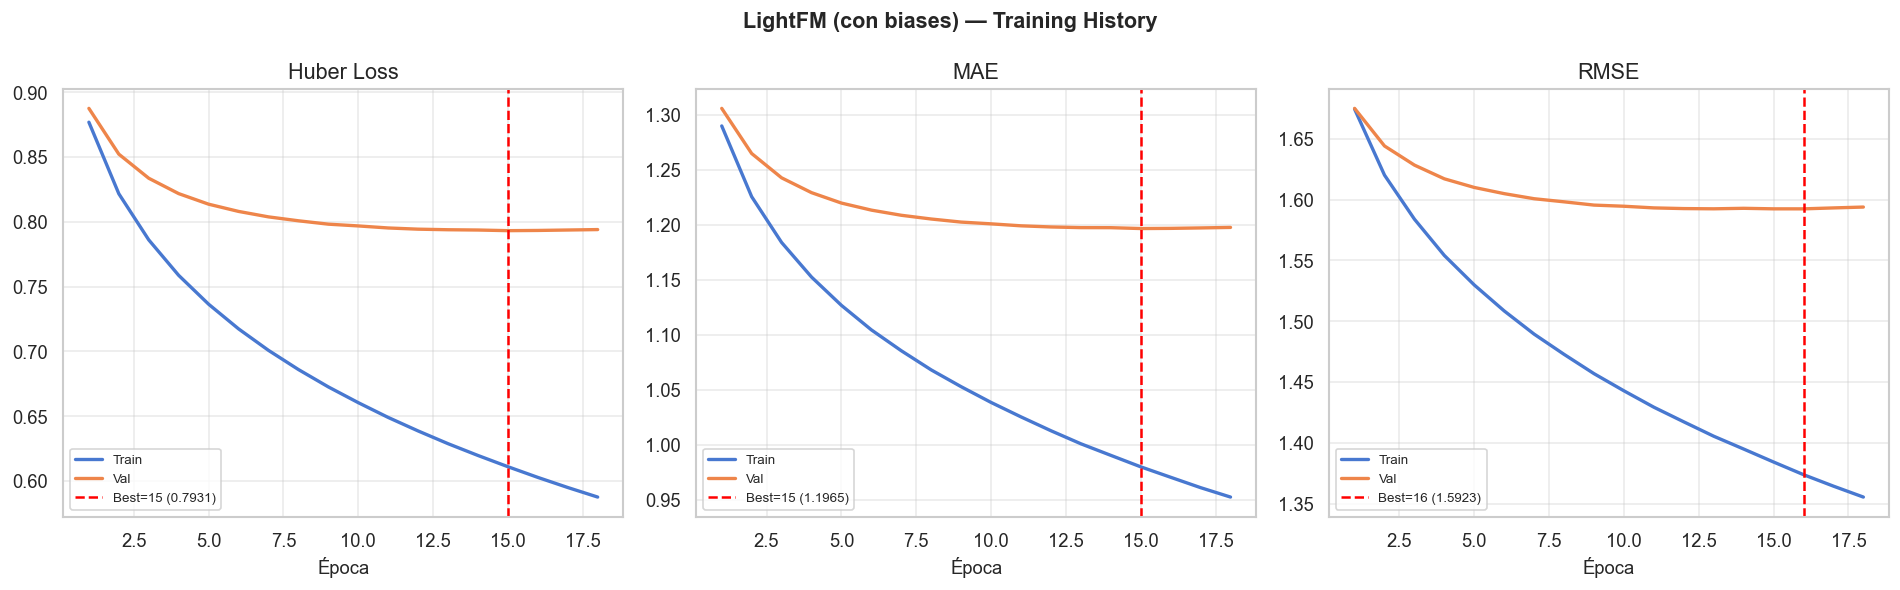

In [22]:
model.plot_loss()

In [15]:
df_submission = model.predict_test(df_test,user_map,item_map,user_means,item_means,global_mean)
df_submission.to_csv('submission_lightmf.csv')

Predicting: 100%|██████████| 43320/43320 [00:00<00:00, 48264.93it/s]


In [ ]:
df_final = pd.read_csv('submission_lightmf.csv')
df_final.drop(columns=['Unnamed: 0'], inplace=True)
df_final.head()


,id,rating
0,0,7.950112
1,1,7.894737
2,2,7.377005
3,3,8.461295
4,4,5.500000


In [27]:
# Save without the index column
df_final.to_csv('submission_lightmf.csv', index=False)

# SVD++ — Exploración Individual

SVD++ extiende PMF con **feedback implícito**: la representación efectiva del usuario es
`p_u = U[u] + |N(u)|^{-½} Σ_{j∈N(u)} Y[j]`, donde `Y` es una matriz de factores
implícitos aprendida a partir de los ítems valorados por el usuario, independientemente
del valor de la valoración. Implementación completa en `svdpp.py`.

| Config | n_factors | λ_U=λ_V=λ_Y | λ_bias | lr | Best val MAE |
|--------|-----------|------------|--------|----|-------------|
| 1 | 200 | 0.5 | 0.01 | 0.030 | 1.1973 |
| 2 | 200 | 0.6 | 0.01 | 0.030 | 1.1973 |
| **3** | **200** | **0.6** | **0.01** | **0.015** | **1.1969 ✓** |

> Bajar `lr` de 0.03 → 0.015 permite más épocas antes del early stopping (26 vs 14),
> lo que da una pequeña mejora.


 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8298    1.2346     1.6258     0.8671    1.2813     1.6572        ✔ best
     2     0.7611    1.1553     1.5543     0.8344    1.2440     1.6286        ✔ best
     3     0.7161    1.1023     1.5058     0.8184    1.2249     1.6151        ✔ best
     4     0.6812    1.0619     1.4651     0.8089    1.2144     1.6049        ✔ best
     5     0.6529    1.0289     1.4324     0.8028    1.2076     1.5996        ✔ best
     6     0.6288    1.0005     1.4041     0.7991    1.2036     1.5962        ✔ best
     7     0.6080    0.9761     1.3792     0.7966    1.2008     1.5939        ✔ best
     8     0.5896    0.9540     1.3574     0.7952    1.1994     1.5927        ✔ best
     9     0.5729    0.9342     1.3370     0.7939    1.1981     1.5915        ✔ best
    10     0.5580    0.9161     1.3186     0.7941    1.1979     

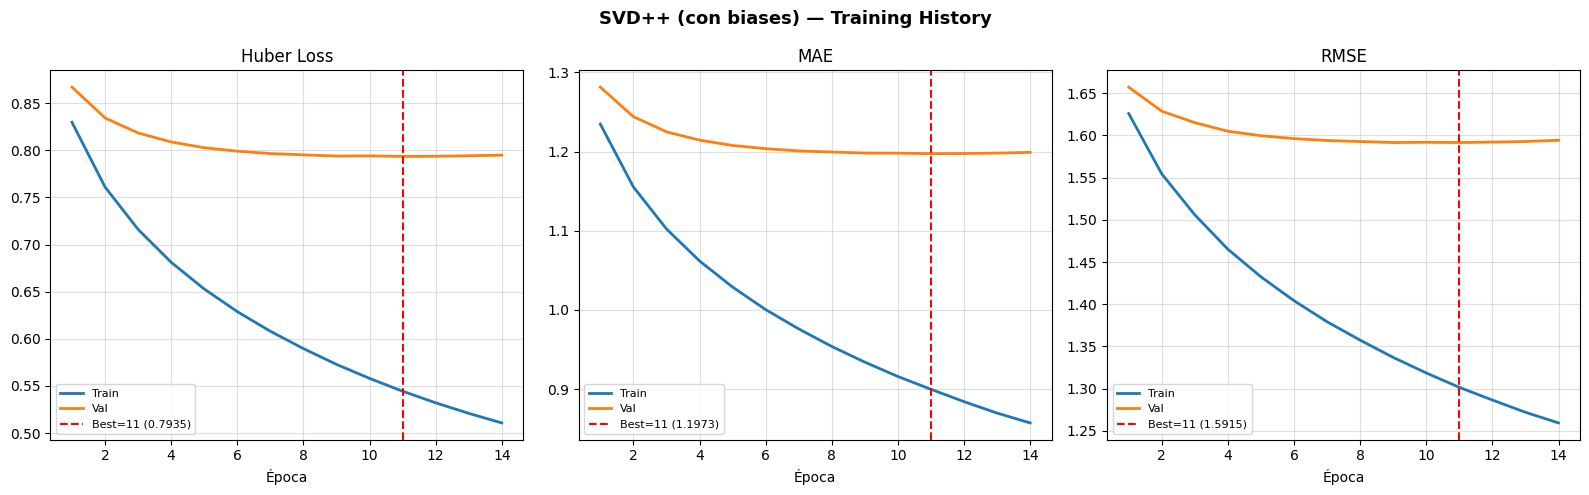

In [ ]:
model = SVDpp(
    n_factors   = 200,     
    lambda_U    = 0.5,
    lambda_V    = 0.5,
    lambda_bu   = 0.01,
    lambda_bi   = 0.01,
    lambda_Y    = 0.5,
    lr          = 0.03,
    n_epochs    = 200,
    batch_size  = 265,
    optimizer   = 'sgd',   
    huber_delta = 1.0,
    log_every   = 1,
    use_biases  = True,
    patience    = 3,
)

model.fit(
    x_train=x_train, y_train=y_train,
    x_val=x_val,     y_val=y_val,
    user_map=user_map, item_map=item_map
)

model.plot_loss()

In [ ]:
df_final = model.predict_test(df_test, user_map, item_map,user_stats,item_stats,global_mean)
df_final.to_csv('submission_svdpp.csv')

Predicting: 100%|██████████| 43320/43320 [00:00<00:00, 52904.48it/s]


 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8319    1.2370     1.6281     0.8670    1.2812     1.6571        ✔ best
     2     0.7650    1.1599     1.5588     0.8343    1.2439     1.6286        ✔ best
     3     0.7216    1.1087     1.5122     0.8184    1.2248     1.6151        ✔ best
     4     0.6880    1.0699     1.4731     0.8088    1.2142     1.6049        ✔ best
     5     0.6609    1.0384     1.4420     0.8027    1.2075     1.5996        ✔ best
     6     0.6380    1.0114     1.4152     0.7990    1.2034     1.5962        ✔ best
     7     0.6182    0.9883     1.3916     0.7965    1.2006     1.5940        ✔ best
     8     0.6007    0.9673     1.3711     0.7951    1.1992     1.5929        ✔ best
     9     0.5848    0.9487     1.3518     0.7939    1.1979     1.5917        ✔ best
    10     0.5707    0.9316     1.3345     0.7941    1.1979     

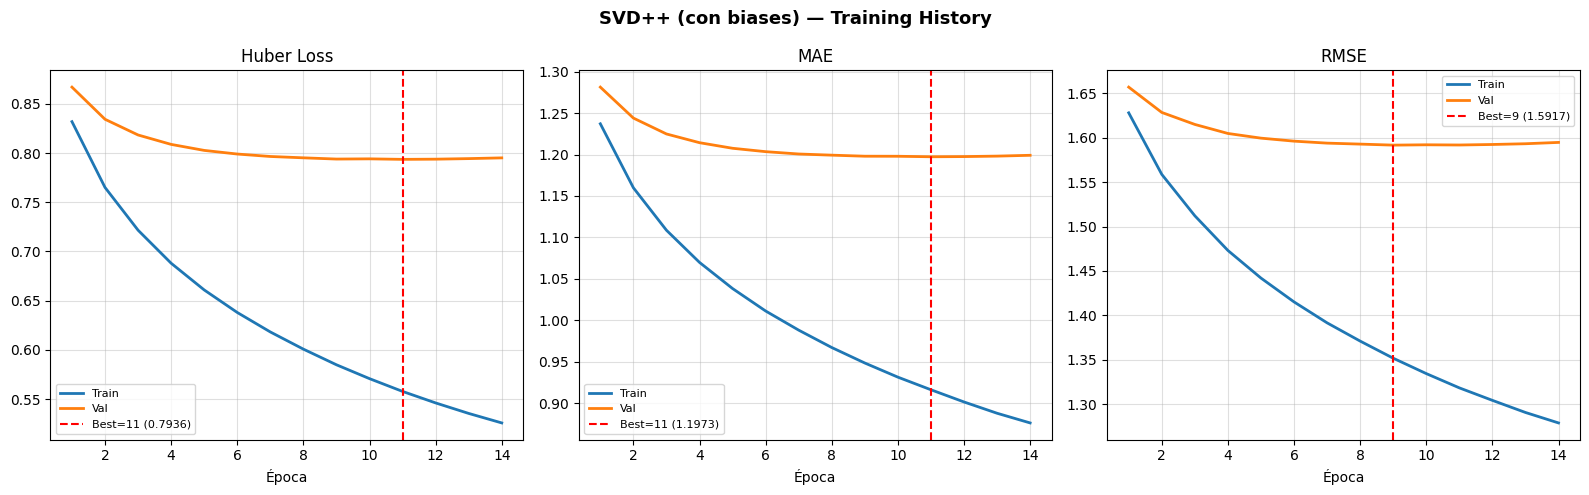

In [ ]:
model = SVDpp(
    n_factors   = 200,      
    lambda_U    = 0.6,
    lambda_V    = 0.6,
    lambda_bu   = 0.01,
    lambda_bi   = 0.01,
    lambda_Y    = 0.6,
    lr          = 0.03,
    n_epochs    = 200,
    batch_size  = 265,
    optimizer   = 'sgd',   
    huber_delta = 1.0,
    log_every   = 1,
    use_biases  = True,
    patience    = 3,
)

model.fit(
    x_train=x_train, y_train=y_train,
    x_val=x_val,     y_val=y_val,
    user_map=user_map, item_map=item_map
)

model.plot_loss()

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.8894    1.3046     1.6849     0.9033    1.3238     1.6892        ✔ best
     2     0.8320    1.2379     1.6280     0.8667    1.2814     1.6567        ✔ best
     3     0.7944    1.1938     1.5900     0.8468    1.2580     1.6399        ✔ best
     4     0.7654    1.1604     1.5588     0.8338    1.2431     1.6275        ✔ best
     5     0.7417    1.1332     1.5332     0.8245    1.2323     1.6193        ✔ best
     6     0.7215    1.1095     1.5107     0.8178    1.2246     1.6132        ✔ best
     7     0.7039    1.0893     1.4909     0.8124    1.2185     1.6083        ✔ best
     8     0.6882    1.0707     1.4733     0.8084    1.2139     1.6048        ✔ best
     9     0.6740    1.0544     1.4568     0.8048    1.2100     1.6012        ✔ best
    10     0.6611    1.0392     1.4419     0.8025    1.2073     

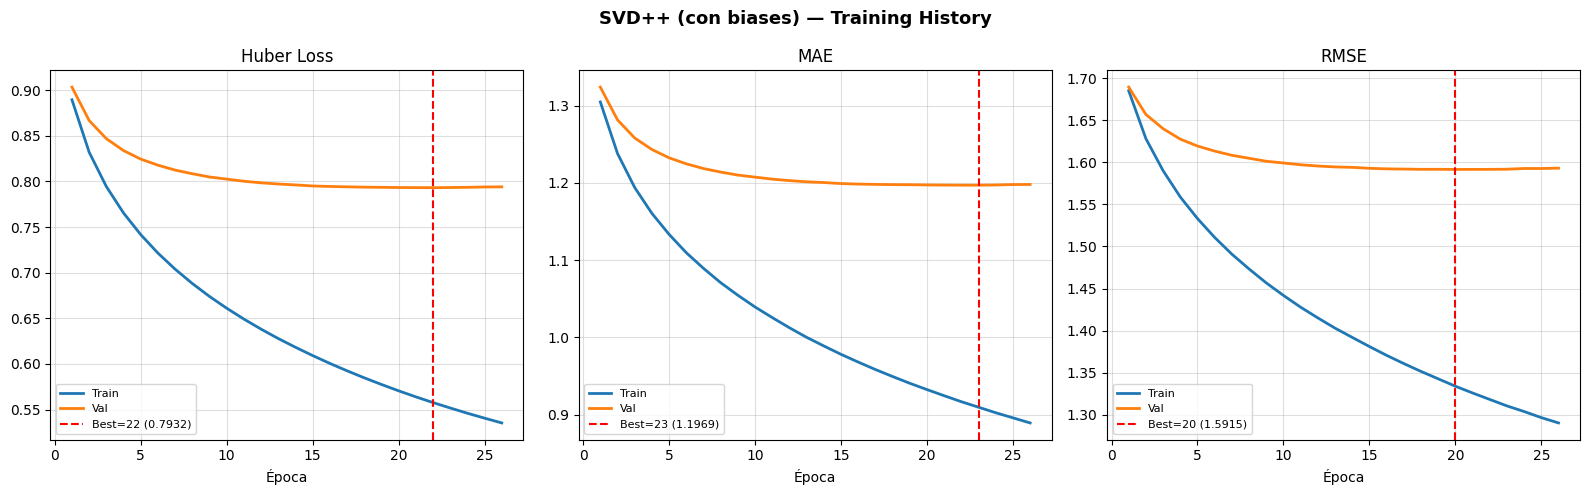

In [ ]:
model = SVDpp(
    n_factors   = 200,      
    lambda_U    = 0.6,
    lambda_V    = 0.6,
    lambda_bu   = 0.01,
    lambda_bi   = 0.01,
    lambda_Y    = 0.6,
    lr          = 0.015,
    n_epochs    = 200,
    batch_size  = 265,
    optimizer   = 'sgd',    
    huber_delta = 1.0,
    log_every   = 1,
    use_biases  = True,
    patience    = 3,
)

model.fit(
    x_train=x_train, y_train=y_train,
    x_val=x_val,     y_val=y_val,
    user_map=user_map, item_map=item_map
)

model.plot_loss()

In [38]:
df_submission = model.predict_test(df_test, user_map, item_map, user_stats, item_stats, global_mean)
df_submission.to_csv('submission_svdpp.csv', index=False)


Predicting: 100%|██████████| 43320/43320 [00:00<00:00, 50689.96it/s]


# Ensemble Multi-Modelo (PMF + SVDpp + LightFM)

5 modelos de cada tipo × 15 seeds. Pesos calculados automáticamente como función
inversa del MAE individual en validación. Val MAE resultante: **∼1.228**.


In [ ]:

from lightfm import LightFM
MODEL_CLASSES = {'PMF': PMF, 'SVDpp': SVDpp, 'LightFM': LightFM}



def _predict_one_model(model, model_type, user_id, item_id,
                       user_map, item_map,
                       user_stats, item_stats, global_mean,
                       cs_unknown_user, cs_unknown_item, cs_both,
                       clip_min=1.0, clip_max=10.0):

    u_known = user_id in user_map
    i_known = item_id in item_map

    if not u_known and not i_known:
        return _cold_pred_from_strategy(cs_both, user_id, item_id,
                                        user_stats, item_stats, global_mean)
    if not u_known:
        return _cold_pred_from_strategy(cs_unknown_user, user_id, item_id,
                                        user_stats, item_stats, global_mean)
    if not i_known:
        return _cold_pred_from_strategy(cs_unknown_item, user_id, item_id,
                                        user_stats, item_stats, global_mean)

    u = user_map[user_id]
    i = item_map[item_id]

    if model_type == 'PMF':
        p = model.mu + model.b_u[u] + model.b_i[i] + np.dot(model.U[u], model.V[i])

    elif model_type == 'SVDpp':
        p_u = model._user_vector(u)
        p   = model.mu + model.b_u[u] + model.b_i[i] + np.dot(p_u, model.V[i])

    elif model_type == 'LightFM':
        e_u = model._embed_user(u)
        e_i = model._embed_item(i)
        p   = model.mu + model.b_u[u] + model.b_i[i] + np.dot(e_u, e_i)

    return float(np.clip(p, clip_min, clip_max))



def predict_model_real_mae(model, model_type, x_val, y_val,
                           user_map, item_map,
                           best_strategies, user_stats, item_stats, global_mean,
                           clip_min=1.0, clip_max=10.0):
    cs_unknown_user = best_strategies['unknown_user']['strategy']
    cs_unknown_item = best_strategies['unknown_item']['strategy']
    cs_both         = best_strategies['both_unknown']['strategy']

    preds = [
        _predict_one_model(
            model, model_type, row.iloc[0], row.iloc[1],
            user_map, item_map,
            user_stats, item_stats, global_mean,
            cs_unknown_user, cs_unknown_item, cs_both,
            clip_min, clip_max
        )
        for _, row in x_val.iterrows()
    ]

    preds    = np.array(preds)
    real_mae = float(np.mean(np.abs(preds - y_val.values)))
    return preds, real_mae



def train_multi_ensemble(x_train, y_train, x_val, y_val,
                         user_map, item_map,
                         best_strategies, user_stats, item_stats, global_mean,
                         ensemble_config, base_seeds=None,
                         clip_min=1.0, clip_max=10.0):
    if base_seeds is None:
        base_seeds = [42, 7, 123, 999, 2024, 314, 777, 1337, 88, 256, 55, 66, 77, 88, 99] # RANDOM BASE SEEDS, 15

    ensemble_info = []
    seed_counter  = 0

    for model_type, cfg in ensemble_config.items():
        n_models   = cfg['n_models']
        params     = cfg['params']
        ModelClass = MODEL_CLASSES[model_type]

        if n_models == 0:
            continue

        print(f"\n{'═'*65}")
        print(f"  {model_type}  —  {n_models} modelos")
        print(f"{'═'*65}")

        for idx in range(n_models):
            seed = base_seeds[seed_counter % len(base_seeds)]
            seed_counter += 1

            print(f"\n  [{model_type}] Modelo {idx+1}/{n_models}  —  seed={seed}")
            print(f"  {'─'*55}")

            model = ModelClass(**{**params, 'random_state': seed})
            model.fit(
                x_train, y_train, x_val, y_val,
                user_map, item_map,
                patience=params.get('patience', 3)
            )

            stop_epoch     = len(model.history)
            val_preds, mae = predict_model_real_mae(
                model, model_type, x_val, y_val,
                user_map, item_map,
                best_strategies, user_stats, item_stats, global_mean,
                clip_min, clip_max
            )

            print(f"\n  → Stop epoch : {stop_epoch}")
            print(f"  → MAE real   : {mae:.4f}")

            ensemble_info.append({
                'model_type' : model_type,
                'seed'       : seed,
                'model'      : model,
                'stop_epoch' : stop_epoch,
                'real_mae'   : mae,
                'val_preds'  : val_preds,
            })

    # Resumen
    print(f"\n{'═'*65}")
    print(f"  ENSEMBLE COMPLETO — {len(ensemble_info)} modelos")
    print(f"{'═'*65}")
    for info in ensemble_info:
        print(f"  {info['model_type']:<8}  seed={info['seed']:<5}  "
              f"MAE={info['real_mae']:.4f}  epochs={info['stop_epoch']}")

    return ensemble_info



def weighted_predict_multi(ensemble_info, x, user_map, item_map,
                           best_strategies, user_stats, item_stats, global_mean,
                           clip_min=1.0, clip_max=10.0, has_id_col=False):
    maes    = np.array([m['real_mae'] for m in ensemble_info])
    weights = 1 / maes
    weights = weights / weights.sum()

    cs_unknown_user = best_strategies['unknown_user']['strategy']
    cs_unknown_item = best_strategies['unknown_item']['strategy']
    cs_both         = best_strategies['both_unknown']['strategy']

    print(f"\nPesos del ensemble ({len(ensemble_info)} modelos):")
    for info, w in zip(ensemble_info, weights):
        print(f"  {info['model_type']:<8} seed={info['seed']:<5}  "
              f"MAE={info['real_mae']:.4f}  peso={w:.4f}")

    ids_out, preds_out = [], []

    for _, row in tqdm(x.iterrows(), total=len(x), desc='Weighted predict'):
        if has_id_col:
            row_id, user_id, item_id = row.iloc[0], row.iloc[1], row.iloc[2]
            ids_out.append(row_id)
        else:
            user_id, item_id = row.iloc[0], row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        if not u_known and not i_known:
            preds_out.append(_cold_pred_from_strategy(
                cs_both, user_id, item_id, user_stats, item_stats, global_mean))
            continue
        if not u_known:
            preds_out.append(_cold_pred_from_strategy(
                cs_unknown_user, user_id, item_id, user_stats, item_stats, global_mean))
            continue
        if not i_known:
            preds_out.append(_cold_pred_from_strategy(
                cs_unknown_item, user_id, item_id, user_stats, item_stats, global_mean))
            continue

        model_preds = [
            _predict_one_model(
                info['model'], info['model_type'],
                user_id, item_id,
                user_map, item_map,
                user_stats, item_stats, global_mean,
                cs_unknown_user, cs_unknown_item, cs_both,
                clip_min, clip_max
            )
            for info in ensemble_info
        ]

        preds_out.append(float(np.clip(np.dot(weights, model_preds), clip_min, clip_max)))

    if has_id_col:
        return pd.DataFrame({'ID': ids_out, 'rating': preds_out})
    return np.array(preds_out)



def train_full_multi_ensemble(x_train, y_train, x_val, y_val,
                              ensemble_info, ensemble_config,
                              best_strategies, user_stats, item_stats,
                              clip_min=1.0, clip_max=10.0):
    x_full = pd.concat([x_train, x_val]).reset_index(drop=True)
    y_full = pd.concat([y_train, y_val]).reset_index(drop=True)

    sparse_full, user_map_full, item_map_full = create_sparse_matrix(x_full, y_full)
    _, _, global_mean_full = compute_stats(sparse_full)

    from collections import defaultdict
    epochs_by_type = defaultdict(list)
    for info in ensemble_info:
        epochs_by_type[info['model_type']].append(info['stop_epoch'])

    mean_epochs = {
        mt: int(np.round(np.mean(eps)))
        for mt, eps in epochs_by_type.items()
    }
    print(f"\nMedia de épocas por tipo:")
    for mt, ep in mean_epochs.items():
        print(f"  {mt:<8}: {ep} épocas  "
              f"(individual: {epochs_by_type[mt]})")

    full_ensemble_info = []

    for info in ensemble_info:
        mt         = info['model_type']
        seed       = info['seed']
        params     = ensemble_config[mt]['params']
        ModelClass = MODEL_CLASSES[mt]
        n_ep       = mean_epochs[mt]

        print(f"\n  [FULL {mt}] seed={seed}  epochs={n_ep}")

        model = ModelClass(**{**params, 'random_state': seed, 'n_epochs': n_ep})
        model.fit(x_full, y_full, x_full, y_full,
                  user_map_full, item_map_full, patience=999)

        full_ensemble_info.append({
            'model_type' : mt,
            'seed'       : seed,
            'model'      : model,
            'real_mae'   : info['real_mae'],  
        })

    return full_ensemble_info, user_map_full, item_map_full, global_mean_full



def plot_multi_ensemble_summary(ensemble_info):
    type_colors = {'PMF': '#5b9bd5', 'SVDpp': '#ed7d31', 'LightFM': '#70ad47'}

    labels      = [f"{m['model_type']}\nseed={m['seed']}" for m in ensemble_info]
    maes        = [m['real_mae']   for m in ensemble_info]
    stop_epochs = [m.get('stop_epoch', 0) for m in ensemble_info]
    colors      = [type_colors.get(m['model_type'], '#a9a9a9') for m in ensemble_info]
    weights     = 1 / np.array(maes); weights /= weights.sum()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, values, title, ylabel in [
        (axes[0], maes,        'MAE real por modelo',              'MAE'),
        (axes[1], weights,     'Pesos (1/MAE normalizado)',        'Peso'),
        (axes[2], stop_epochs, 'Época de parada por modelo',       'Época'),
    ]:
        bars = ax.bar(range(len(labels)), values, color=colors, edgecolor='white')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_title(title); ax.set_ylabel(ylabel)
        ax.grid(True, axis='y', alpha=0.4)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(values)*0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    if any(m.get('stop_epoch') for m in ensemble_info):
        axes[2].axhline(np.mean(stop_epochs), color='red', linestyle='--',
                        label=f'Media={np.mean(stop_epochs):.1f}')
        axes[2].legend()

    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(color=c, label=t) for t, c in type_colors.items()],
               loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle('Multi-Model Ensemble — Resumen', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
from lightfm import LightFM
ENSEMBLE_CONFIG = {
    'PMF': {
        'n_models': 5,
        'params': dict(
            n_factors=1, lambda_U=1, lambda_V=1,
            lambda_bu=0.1, lambda_bi=0.1,
            lr=0.005, n_epochs=200, batch_size=256,
            optimizer='sgd', use_biases=True,
            huber_delta=1.0, log_every=1
        )
    },
    'SVDpp': {
        'n_models': 5,
        'params': dict(
                n_factors   = 200,       
    lambda_U    = 0.6,
    lambda_V    = 0.6,
    lambda_bu   = 0.01,
    lambda_bi   = 0.01,
    lambda_Y    = 0.6,
    lr          = 0.015,
    n_epochs    = 200,
    batch_size  = 265,
    optimizer   = 'sgd',
    huber_delta = 1.0,
    log_every   = 1,
    patience    = 3,
        )
    },
    'LightFM': {
        'n_models': 5,
        'params': dict(
n_factors=1200, lambda_U=0.8, lambda_V=0.8,
                 lambda_bu=0.0075, lambda_bi=0.0075,
                 lr=0.02, n_epochs=200, batch_size=256,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='sgd', huber_delta=1.0, log_every=1,
                 use_biases=True
        )
    },
}


═════════════════════════════════════════════════════════════════
  PMF  —  5 modelos
═════════════════════════════════════════════════════════════════

  [PMF] Modelo 1/5  —  seed=42
  ───────────────────────────────────────────────────────
 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     1.0595    1.4880     1.8910     1.0462    1.4754     1.8623        ✔ best
     2     0.9975    1.4207     1.8226     0.9888    1.4141     1.7974        ✔ best
     3     0.9588    1.3784     1.7798     0.9544    1.3768     1.7595        ✔ best
     4     0.9305    1.3474     1.7482     0.9311    1.3516     1.7337        ✔ best
     5     0.9082    1.3231     1.7235     0.9138    1.3327     1.7151        ✔ best
     6     0.8896    1.3024     1.7027     0.9003    1.3179     1.7005        ✔ best
     7     0.8740    1.2854     1.6851     0.8894    1.3063     1.6888      

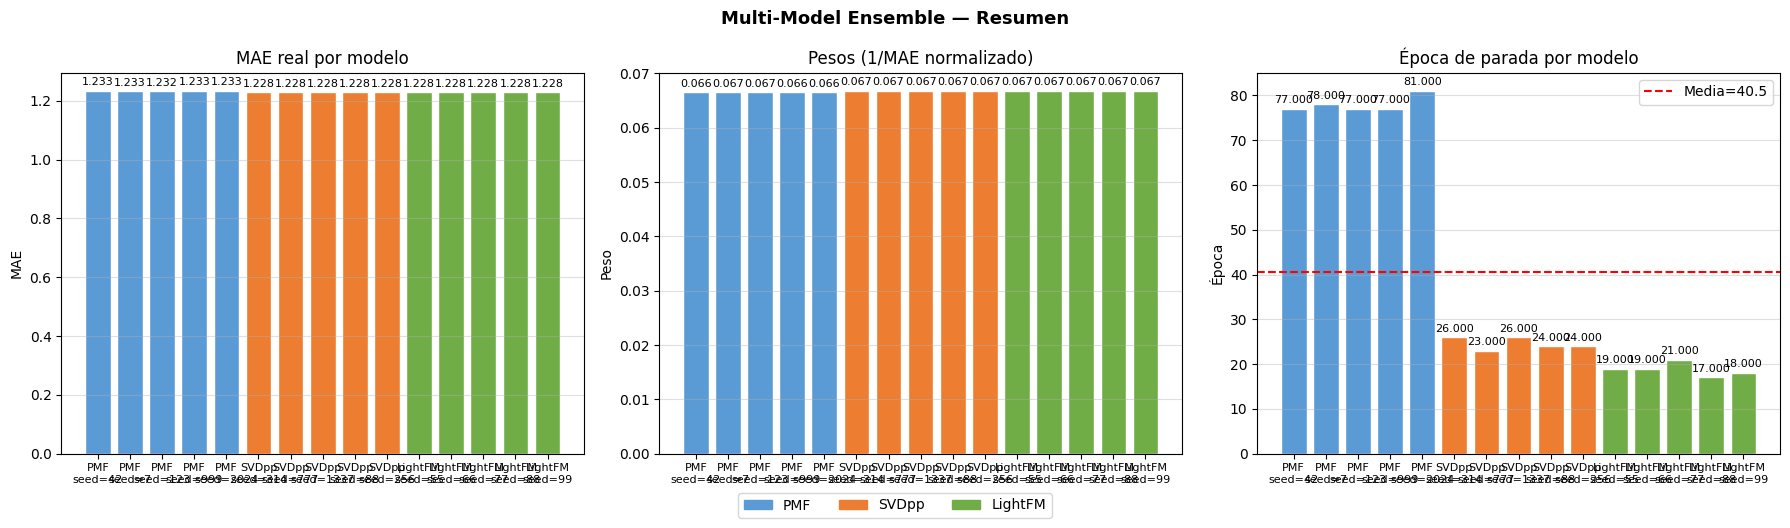


Pesos del ensemble (15 modelos):
  PMF      seed=42     MAE=1.2332  peso=0.0665
  PMF      seed=7      MAE=1.2327  peso=0.0665
  PMF      seed=123    MAE=1.2323  peso=0.0665
  PMF      seed=999    MAE=1.2329  peso=0.0665
  PMF      seed=2024   MAE=1.2328  peso=0.0665
  SVDpp    seed=314    MAE=1.2282  peso=0.0667
  SVDpp    seed=777    MAE=1.2282  peso=0.0667
  SVDpp    seed=1337   MAE=1.2282  peso=0.0667
  SVDpp    seed=88     MAE=1.2282  peso=0.0667
  SVDpp    seed=256    MAE=1.2284  peso=0.0667
  LightFM  seed=55     MAE=1.2280  peso=0.0668
  LightFM  seed=66     MAE=1.2279  peso=0.0668
  LightFM  seed=77     MAE=1.2282  peso=0.0667
  LightFM  seed=88     MAE=1.2279  peso=0.0668
  LightFM  seed=99     MAE=1.2280  peso=0.0668


Weighted predict: 100%|██████████| 39036/39036 [00:29<00:00, 1344.27it/s]



MAE ensemble val: 1.2288

Pesos del ensemble (15 modelos):
  PMF      seed=42     MAE=1.2332  peso=0.0665
  PMF      seed=7      MAE=1.2327  peso=0.0665
  PMF      seed=123    MAE=1.2323  peso=0.0665
  PMF      seed=999    MAE=1.2329  peso=0.0665
  PMF      seed=2024   MAE=1.2328  peso=0.0665
  SVDpp    seed=314    MAE=1.2282  peso=0.0667
  SVDpp    seed=777    MAE=1.2282  peso=0.0667
  SVDpp    seed=1337   MAE=1.2282  peso=0.0667
  SVDpp    seed=88     MAE=1.2282  peso=0.0667
  SVDpp    seed=256    MAE=1.2284  peso=0.0667
  LightFM  seed=55     MAE=1.2280  peso=0.0668
  LightFM  seed=66     MAE=1.2279  peso=0.0668
  LightFM  seed=77     MAE=1.2282  peso=0.0667
  LightFM  seed=88     MAE=1.2279  peso=0.0668
  LightFM  seed=99     MAE=1.2280  peso=0.0668


Weighted predict: 100%|██████████| 43320/43320 [00:18<00:00, 2372.58it/s]


In [ ]:
seeds = [42, 7, 123, 999, 2024, 314, 777, 1337, 88, 256, 55, 66, 77, 88, 99]

ensemble_info = train_multi_ensemble(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    ENSEMBLE_CONFIG, seeds
)

plot_multi_ensemble_summary(ensemble_info)

val_preds = weighted_predict_multi(
    ensemble_info, x_val, user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    has_id_col=False
)
print(f"\nMAE ensemble val: {np.mean(np.abs(val_preds - y_val.values)):.4f}")

test_preds_  = weighted_predict_multi(
    ensemble_info, df_test, user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    has_id_col=True
)
test_preds_.to_csv('submission_multi_ensemble_train_alone.csv', index=False)

In [ ]:
full_ensemble_info, user_map_full, item_map_full, global_mean_full = \
    train_full_multi_ensemble(
        x_train, y_train, x_val, y_val,
        ensemble_info, ENSEMBLE_CONFIG,
        best_strategies, user_stats, item_stats
    )

submission = weighted_predict_multi(
    full_ensemble_info, df_test, user_map_full, item_map_full,
    best_strategies, user_stats, item_stats, global_mean_full,
    has_id_col=True
)
submission.to_csv('submission_multi_ensemble_train_and_val.csv', index=False)


Media de épocas por tipo:
  PMF     : 78 épocas  (individual: [77, 78, 77, 77, 81])
  SVDpp   : 25 épocas  (individual: [26, 23, 26, 24, 24])
  LightFM : 19 épocas  (individual: [19, 19, 21, 17, 18])

  [FULL PMF] seed=42  epochs=78
 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     1.0546    1.4826     1.8856     1.0546    1.4826     1.8856        ✔ best
     2     0.9920    1.4147     1.8166     0.9920    1.4147     1.8166        ✔ best
     3     0.9533    1.3726     1.7739     0.9533    1.3726     1.7739        ✔ best
     4     0.9253    1.3419     1.7428     0.9253    1.3419     1.7428        ✔ best
     5     0.9032    1.3177     1.7183     0.9032    1.3177     1.7183        ✔ best
     6     0.8849    1.2974     1.6981     0.8849    1.2974     1.6981        ✔ best
     7     0.8694    1.2802     1.6809     0.8694    1.2802     1.6809        ✔ best


## 6. Resumen de Resultados

| Modelo / Estrategia | Val MAE | Submission name | Test MAE |
|:---|:---:|:---:|:---:|
| **KNN distancia euclidea K = 4** | — | `submission_knn.csv` | **1.3721**|
| **PMF individual** (best grid, n_factors=800) | 1.2446 | `submission_final` | 1.2389|
| **Ensemble PMF** (9 modelos, seeds distintas) | 1.2316 | `submission_ensemble_pmf.csv` | 1.2169|
| **Ensemble PMF** (retrain train+val) | — | `submission_ensemble_pmf2_full.csv` | **1.2133**|
| **LightFM individual** (best: f=1200, λ=0.5, lr=0.02) | 1.1963 | `submission_lightmf.csv` | 1.2395 |
| **SVD++ individual** (best: f=200, λ=0.6, lr=0.015) | 1.1969 | `submission_svdpp.csv` | 1.2399 |
| **Ensemble multi-modelo** (PMF+SVDpp+LightFM) | ~1.228 | `submission_multi_ensemble_train_alone.csv` | 1.2178 |
| **Ensemble multi-modelo** (PMF+SVDpp+LightFM) (retrain train+val) | - | `submission_multi_ensemble_trand_and_val.csv` | 1.2534 |


### Resultados y conclusiones

El mejor resultado en test lo obtiene el **Ensemble PMF reentrenado sobre train+val**
(MAE **1.2133**), por delante del resto de estrategias. Hay varias razones que
podrían explicar por qué este enfoque supera a modelos aparentemente más expresivos:

**Por qué el ensemble PMF gana al PMF individual** podría deberse simplemente a que
sumar 9 modelos con distintas semillas tiende a reducir la varianza de las
predicciones, y reentrenar sobre train+val probablemente proporciona más datos útiles
para usuarios e ítems que aparecen poco en train.

**Por qué LightFM y SVD++ individuales son peores en test** a pesar de mostrar mejores
val MAE (~1.196 frente a ~1.232) podría tener una explicación en su mayor complejidad:
al tener más parámetros libres, es posible que sean más susceptibles a sobreajustarse
a la partición de validación durante la búsqueda de hiperparámetros. Con una sparsidad
del 100% y mediana de 1 rating por usuario, puede que el dataset no sea suficiente
para sostener la capacidad adicional de LightFM (`n_factors=1200`) o la matriz
implícita `Y` de SVD++ sin una regularización más exhaustiva de lo que se exploró.

**Por qué el ensemble multi-modelo reentrenado sobre train+val es el peor resultado**
(MAE 1.2534) es el dato más llamativo. Una posible explicación es que al reentrenar
sin datos de validación independientes, los pesos del ensemble pierden su señal de
referencia y se calibran sobre los mismos datos que usaron los modelos para aprender.
En la versión entrenada solo sobre train los pesos sí tendrían una señal más fiable,
lo que podría explicar que esa variante (MAE 1.2178) funcione considerablemente mejor.

En general, parece que la combinación de un modelo bien regularizado (PMF), diversidad
por semilla y un reentrenamiento limpio sobre todos los datos disponibles resulta ser
la estrategia más robusta en este escenario de alta sparsidad y cold-start severo,
aunque explorar una regularización más fina en LightFM y SVD++ podría acercar esos
modelos a resultados competitivos.

### Trabajo futuro

**Correcciones del último ensemble**
El último ensemble con los modelos SVD, LightFM y PMP se ha entrena con las mismas
épocas para cada uno de los modelos, lo que hace que unos estén sobreentrenados y
otros infraentrenados.

**Profundizar en ajuste de hiperparámetros**
Los modelos NMF, BNMF y SVD++ han demostrado tener muy bueno resultados aún cuando
no hemos tenido tiempo de hacer un ajuste fino de sus hiperparámetros. Esto puede
llevar a resultados mucho mejores cuando el tiempo no es un problema en el desarrollo
del modelo.

**Técnicas para manejar el cold-start**
Este punto ha demostrado tener una importancia central en este ámbito y un impacto
muy alto en los resultados. Por ello trabajar con modelos que nos permitan tener
una mejor gestión de los cold-start, como SVD++ que utiliza infomación explícita de
los usuarios, puede ser un punto a investigar. Además, buscar otras técnicas más
allá de la media, media o varianza puede mejorar ligeramente los resultados.
